In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import re
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from PIL import Image
import statsmodels.api as sm
import scipy.stats as stats

import io
import os
from shapely import wkt
from matplotlib_scalebar.scalebar import ScaleBar

from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import BaggingRegressor 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from xgboost import XGBRegressor
import shap
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphClass import CausalGraph
from causallearn.graph.GraphNode import GraphNode
from causallearn.utils.GraphUtils import GraphUtils

from econml.dml import LinearDML
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

def import_csv_w_wkt_to_gdf(path,crs,geometry_col='geometry',gc='default'):
	if gc=='default': # standard read_csv without specifying a column to import as string
		df = pd.read_csv(path,encoding='latin-1')
	else: #  read_csv with a geocode (or other) column being specified as a string data type
		df = pd.read_csv(path,encoding='latin-1',dtype={gc:str})
	gdf = gpd.GeoDataFrame(df, 
						geometry=df[geometry_col].apply(wkt.loads),
						crs=crs)
	return(gdf)


In [2]:
df=pd.read_csv('mobility_data_full.csv',dtype={'geocode':str})
df.rename(columns={'Distance2Center':'Distance to Center','Urb_Pop_Density':'Urban Pop. Density','SF_share':'Single-family Share','transit_access':'Transit Accessibility','tCO2cap_mob':'Mobility CO2/cap','City_Pop':'City Population','pkm_cap_Car':'p-km/cap car','pkm_cap_Transit':'p-km/cap transit','Car_cap':'Car/cap','minDist_subcenter':'Min. dist to Subcenter',  
'clean_intersection_density_km':'intersec_density', 'street_density_km':'street_density',   'bike_lane_share':'bike_lane_ratio'},inplace=True)

df.loc[df['Country_Germany']==1,'Inc_HH']=12*df.loc[df['Country_Germany']==1,'Inc_HH']
df.loc[df['Country_Germany']==1,'Inc_cap']=12*df.loc[df['Country_Germany']==1,'Inc_cap']
df['share_65+']=100*df['share_65+']

x_vars=['Urban Pop. Density','Distance to Center', 'Single-family Share', 'Transit Accessibility']
# x_vars_alt=['Min. dist to Subcenter','Urb_Build_Density']
y_vars=['p-km/cap car','p-km/cap transit','Car/cap','Mobility CO2/cap']


In [4]:
scaler = StandardScaler()
# Apply standardizer per country group
df['Inc_cap_std'] = df.groupby('Country')['Inc_cap'].transform(
    lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).ravel()
)
df['Inc_cap_global'] = scaler.fit_transform(df[['Inc_cap']])


In [5]:
mean_inc=round(df.groupby(['Region'])['Inc_cap','Inc_cap_std','Inc_cap_global'].mean().reset_index(),2)
mean_inc.to_csv('datapaper_outputs/income_raw_comp.csv',index=False)
mean_inc

Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.


,Region,Inc_cap,Inc_cap_std,Inc_cap_global
0,Berlin,16154.22,0.03,-1.23
1,Clermont,23907.16,-0.16,0.22
2,Dijon,23911.63,-0.16,0.22
3,Dresden,13920.05,-0.82,-1.65
4,Düsseldorf,18522.48,0.93,-0.79
5,Leipzig,14676.98,-0.53,-1.51
6,Lille,23342.82,-0.29,0.11
7,Lyon,24969.34,0.08,0.42
8,Montpellier,23480.91,-0.26,0.14
9,Nantes,24707.50,0.02,0.37


Plot linear correlation figures

In [ ]:
variable_labels = {
    # Predictors (x_vars)
    'Transit Accessibility': 'Transit Accessibility (dep/min)',
    'Min. dist to Subcenter': 'Min. Distance to Subcenter (km)',
    'City Population': 'City Population (persons)',
    'Distance to Center': 'Distance to Center (km)',
    'HH_size': 'Household Size (persons/HH)',
    'share_65+': 'Population aged 65+ (%)',
    'Inc_cap_std': 'Relative Income per Capita (z-score)',
    'intersec_density': 'Street Intersection Density (N/km²)',
    'street_density':'Street Density (m/km²)',
    'Single-family Share':'Single-family Share (%)',
    'Urban Pop. Density': 'Urban Pop. Density (per/ha)',
    'bike_lane_ratio':'Bike lane ratio [-]',
    
    # Outcomes (y_vars) - replace these with your exact y variable column names
    'p-km/cap car': 'Car Travel (pkm/cap/yr)',
    'p-km/cap transit': 'Transit Travel (pkm/cap)',
    'Mobility CO2/cap': 'Emissions (tCO₂/cap/yr)',
    'Car/cap':'Car ownership (car/cap)'
}

In [ ]:
variable_labels_2 = {
    # Predictors (x_vars)
    'Transit Accessibility': 'Transit Accessibility (z-score)',
    'Min. dist to Subcenter': 'Min. Distance to Subcenter (z-score)',
    'City Population': 'City Population (z-score)',
    'Distance to Center': 'Distance to Center (z-score)',
    'HH_size': 'Household Size (z-score)',
    'share_65+': 'Population % aged 65+ (z-score)',
    'Inc_cap_std': 'Income per Capita (z-score)',
    'intersec_density': 'Street Intersection Density (z-score)',
    'street_density':'Street Density (z-score)',
    'Single-family Share':'Single-family Share (z-score)',
    'Urban Pop. Density': 'Urban Pop. Density (z-score)',
    'bike_lane_ratio':'Bike lane ratio [z-score]',
    
    # Outcomes (y_vars) - replace these with your exact y variable column names
    'p-km/cap car': 'Car Travel (pkm/cap/yr)',
    'p-km/cap transit': 'Transit Travel (pkm/cap)',
    'Mobility CO2/cap': 'Emissions (tCO₂/cap/yr)',
    'Car/cap':'Car ownership (car/cap)'
}

In [ ]:
variable_labels_3 = {
    # Predictors (x_vars)
    'Transit Accessibility': 'Transit Accessibility',
    'Min. dist to Subcenter': 'Min. Distance to Subcenter',
    'City Population': 'City Population',
    'Distance to Center': 'Distance to Center',
    'HH_size': 'Household Size',
    'share_65+': 'Population % aged 65+',
    'Inc_cap_std': 'Income per Capita',
    'intersec_density': 'Street Intersection Density',
    'street_density':'Street Density',
    'Single-family Share':'Single-family Share',
    'Urban Pop. Density': 'Urban Pop. Density',
    'bike_lane_ratio':'Bike lane ratio',
    'Country_France':'Country',
    
    # Outcomes (y_vars) - replace these with your exact y variable column names
    'p-km/cap car': 'Car Travel',
    'p-km/cap transit': 'Transit Travel',
    'Mobility CO2/cap': 'Emissions',
    'Car/cap':'Car ownership'
}

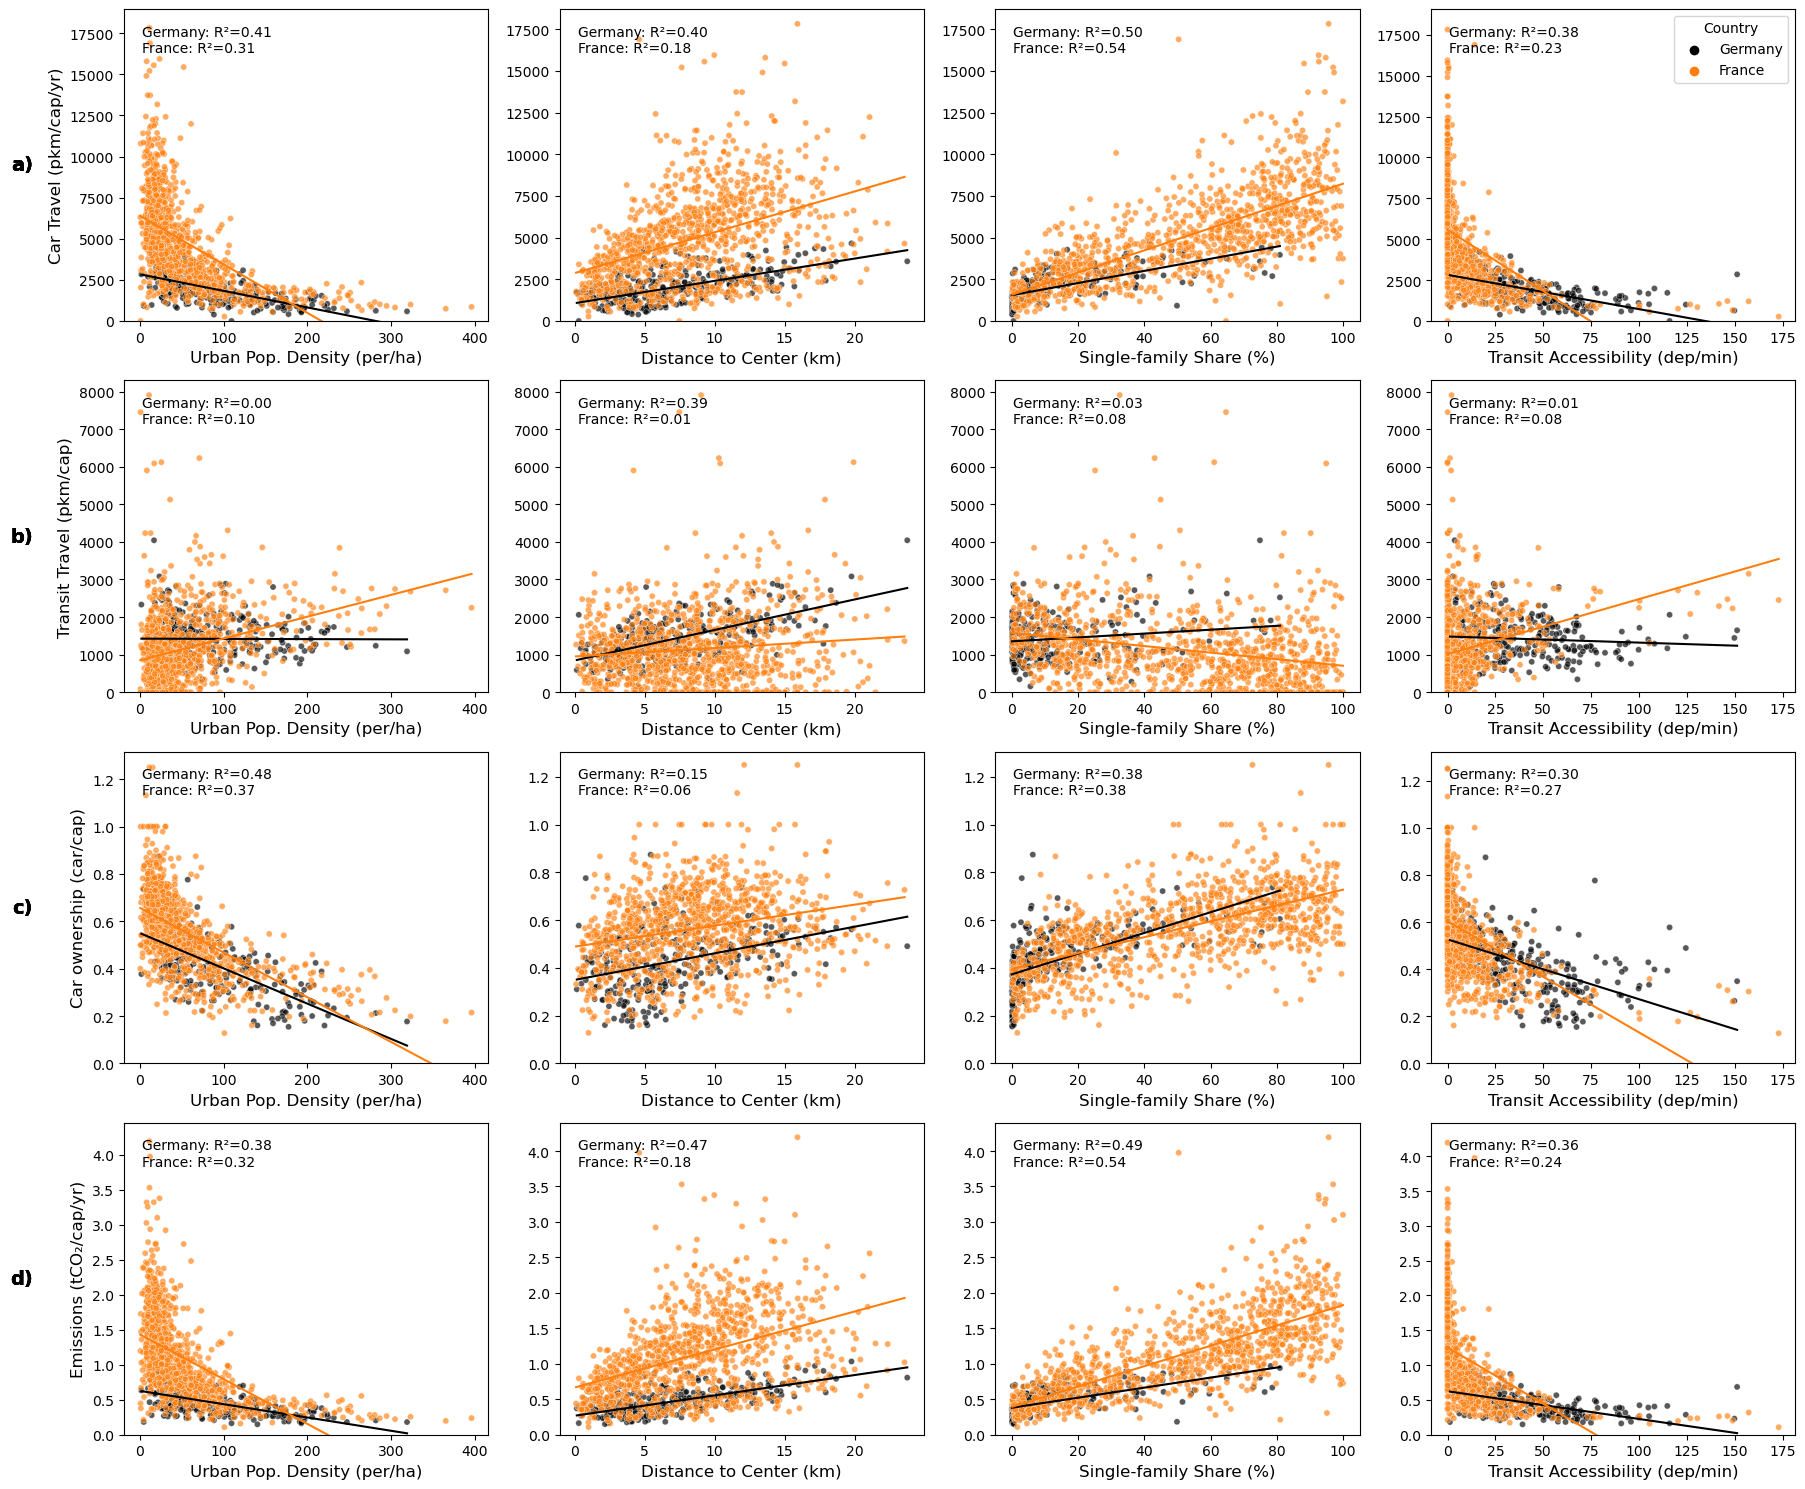

In [ ]:
country_palette = { "Germany": "black", "France": "tab:orange" }
row_labels = ['a)','b)','c)','d)']
fig, axes = plt.subplots(4, 4, figsize=(18, 15))

countries = df["Country"].unique()

for i, y in enumerate(y_vars):
    for j, x in enumerate(x_vars):
        ax = axes[i, j]

        # Extract 1D arrays
        x_data = df[x].values.ravel()
        y_data = df[y].values.ravel()
        country_data = df["Country"].astype(str)
        
        axes[i, 0].text(
            -0.25, 0.5, # position (left of the subplot)
            row_labels[i], # label
            transform=axes[i, 0].transAxes, 
            fontsize=14, 
            fontweight='bold', 
            va='center', 
            ha='right' )

        # Scatterplot (colored by country)
        sns.scatterplot(
            x=x_data,
            y=y_data,
            hue=country_data,
            palette=country_palette,   
            ax=ax,
            s=20,
            alpha=0.65,
            legend=False if not (i == 0 and j == 3) else True
        )

        # --- Per-country regression lines + R² ---
        r2_text = []  # store text for annotation
        r2_values = {}
        #y_pos = 0.95 # starting vertical position
        for c in countries:
            mask = (df["Country"] == c)
            x_c = df.loc[mask, x].values.reshape(-1, 1)
            y_c = df.loc[mask, y].values.ravel()

            # Fit linear regression
            model = LinearRegression().fit(x_c, y_c)
            r2 = model.score(x_c, y_c)
            r2_values[c] = r2

            # Store text for annotation
            r2_text.append(f"{c}: R²={r2:.2f}")

            # Regression line
            x_fit = np.linspace(x_c.min(), x_c.max(), 100).reshape(-1, 1)
            y_fit = model.predict(x_fit)
            ax.plot(x_fit, y_fit, linewidth=1.5,color=country_palette[c], label=f"{c} fit")

        # Annotate R² values
        ax.text(
            0.05, 0.95,
            "\n".join(r2_text),
            # f"{c}: R²={r2_values[c]:.2f}",
            transform=ax.transAxes,
            fontsize=10,
            #color=country_palette[c],
            verticalalignment="top"
        )

        # Fix y-axis lower limit
        ax.set_ylim(bottom=0)

        ax.set_xlabel(variable_labels.get(x, x), fontsize=12)
        if j == 0:
            ax.set_ylabel(variable_labels.get(y, y), fontsize=12)
        else:
            ax.set_ylabel("")
      

plt.tight_layout()
plt.show()
fig.savefig('datapaper_outputs/figures/corrs_linreg.png',dpi=300,facecolor='white')

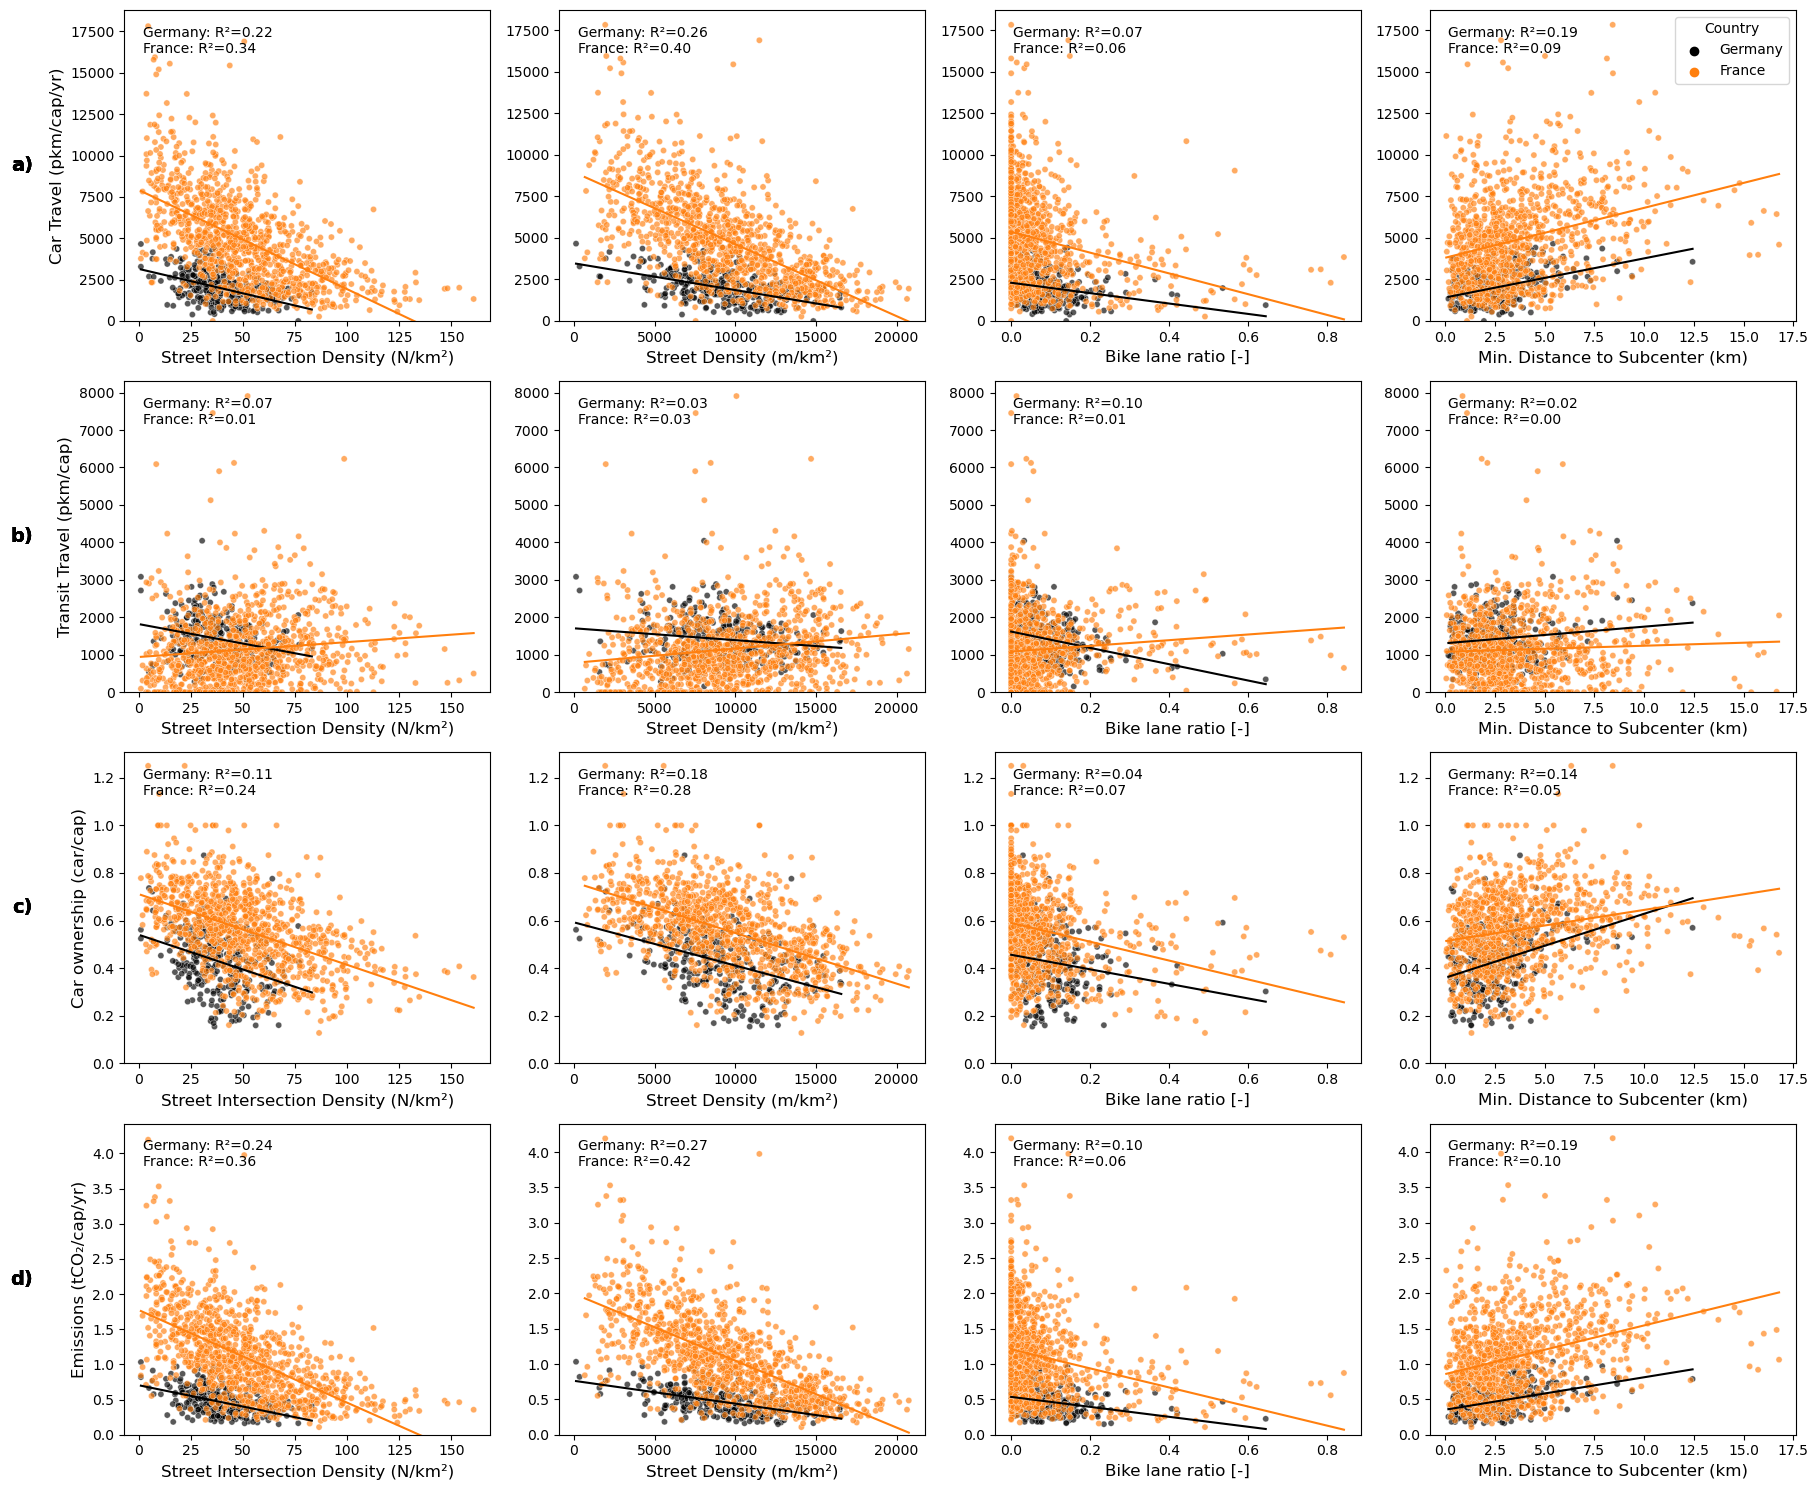

In [ ]:
x_vars_alt=['intersec_density','street_density','bike_lane_ratio','Min. dist to Subcenter']

country_palette = { "Germany": "black", "France": "tab:orange" }
row_labels = ['a)','b)','c)','d)']
fig, axes = plt.subplots(4, 4, figsize=(18, 15))

countries = df["Country"].unique()

for i, y in enumerate(y_vars):
    for j, x in enumerate(x_vars_alt):
        ax = axes[i, j]

        # Extract 1D arrays
        x_data = df[x].values.ravel()
        y_data = df[y].values.ravel()
        country_data = df["Country"].astype(str)
        
        axes[i, 0].text(
            -0.25, 0.5, # position (left of the subplot)
            row_labels[i], # label
            transform=axes[i, 0].transAxes, 
            fontsize=14, 
            fontweight='bold', 
            va='center', 
            ha='right' )

        # Scatterplot (colored by country)
        sns.scatterplot(
            x=x_data,
            y=y_data,
            hue=country_data,
            palette=country_palette,   
            ax=ax,
            s=20,
            alpha=0.65,
            legend=False if not (i == 0 and j == 3) else True
        )

        # --- Per-country regression lines + R² ---
        r2_text = []  # store text for annotation
        r2_values = {}
        #y_pos = 0.95 # starting vertical position
        for c in countries:
            mask = (df["Country"] == c)
            x_c = df.loc[mask, x].values.reshape(-1, 1)
            y_c = df.loc[mask, y].values.ravel()

            # Fit linear regression
            model = LinearRegression().fit(x_c, y_c)
            r2 = model.score(x_c, y_c)
            r2_values[c] = r2

            # Store text for annotation
            r2_text.append(f"{c}: R²={r2:.2f}")

            # Regression line
            x_fit = np.linspace(x_c.min(), x_c.max(), 100).reshape(-1, 1)
            y_fit = model.predict(x_fit)
            ax.plot(x_fit, y_fit, linewidth=1.5,color=country_palette[c], label=f"{c} fit")

        # Annotate R² values
        ax.text(
            0.05, 0.95,
            "\n".join(r2_text),
            # f"{c}: R²={r2_values[c]:.2f}",
            transform=ax.transAxes,
            fontsize=10,
            #color=country_palette[c],
            verticalalignment="top"
        )
        #y_pos -= 0.08

        # Fix y-axis lower limit
        ax.set_ylim(bottom=0)

        ax.set_xlabel(variable_labels.get(x, x), fontsize=12)
        if j == 0:
            ax.set_ylabel(variable_labels.get(y, y), fontsize=12)
        else:
            ax.set_ylabel("")
      

plt.tight_layout()
plt.show()
fig.savefig('datapaper_outputs/figures/corrs_linreg_SI_1.png',dpi=300,facecolor='white')

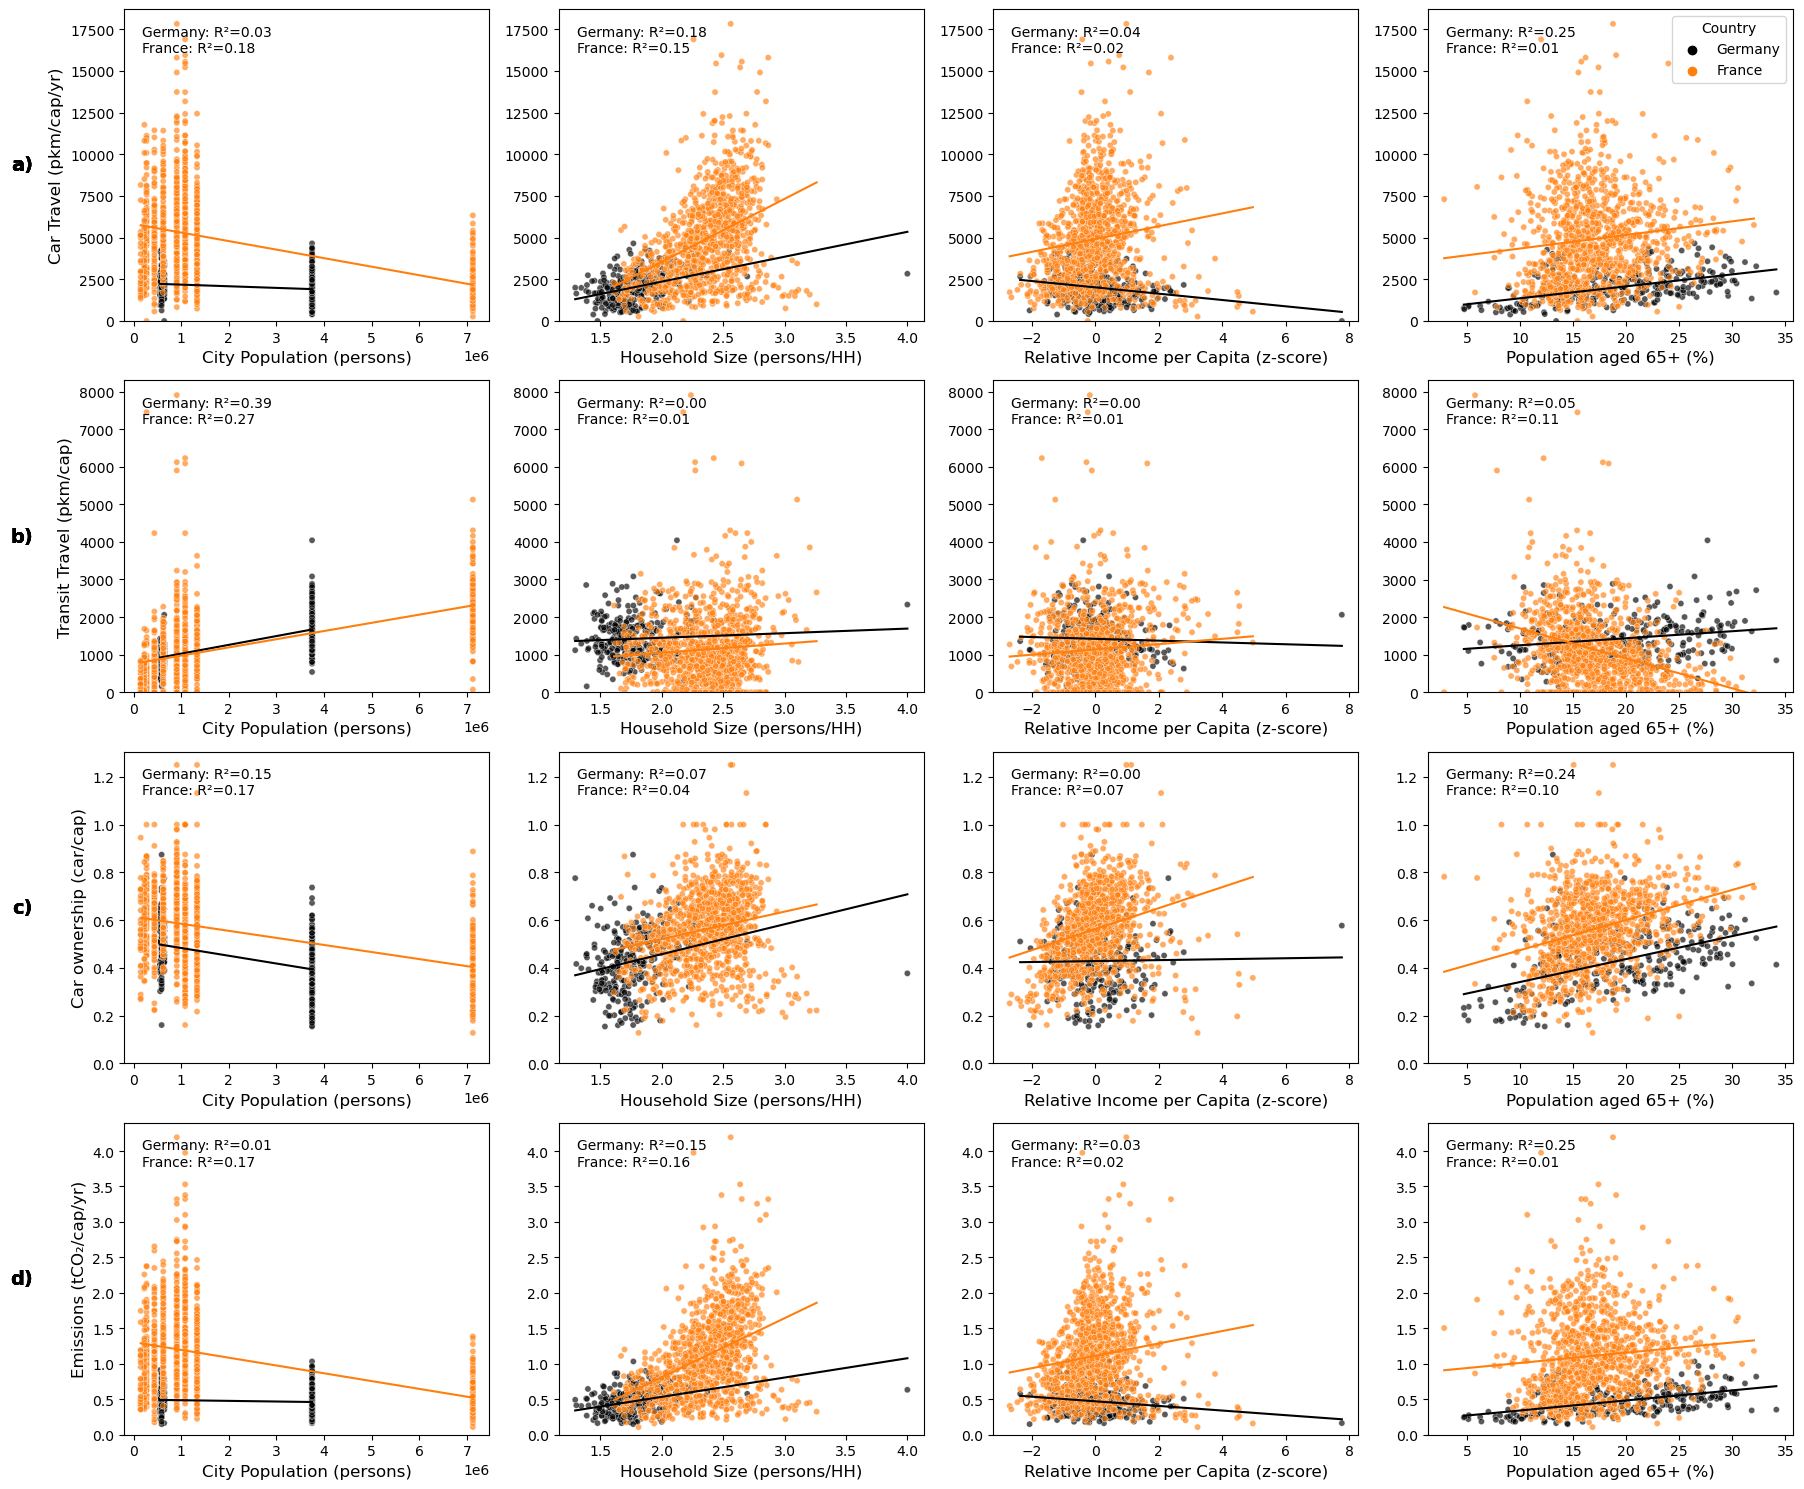

In [ ]:
x_vars_alt=['City Population','HH_size','Inc_cap_std','share_65+']

country_palette = { "Germany": "black", "France": "tab:orange" }
row_labels = ['a)','b)','c)','d)']
fig, axes = plt.subplots(4, 4, figsize=(18, 15))

countries = df["Country"].unique()

for i, y in enumerate(y_vars):
    for j, x in enumerate(x_vars_alt):
        ax = axes[i, j]

        # Extract 1D arrays
        x_data = df[x].values.ravel()
        y_data = df[y].values.ravel()
        country_data = df["Country"].astype(str)
        
        axes[i, 0].text(
            -0.25, 0.5, # position (left of the subplot)
            row_labels[i], # label
            transform=axes[i, 0].transAxes, 
            fontsize=14, 
            fontweight='bold', 
            va='center', 
            ha='right' )

        # Scatterplot (colored by country)
        sns.scatterplot(
            x=x_data,
            y=y_data,
            hue=country_data,
            palette=country_palette,   
            ax=ax,
            s=20,
            alpha=0.65,
            legend=False if not (i == 0 and j == 3) else True
        )

        # --- Per-country regression lines + R² ---
        r2_text = []  # store text for annotation
        r2_values = {}
        #y_pos = 0.95 # starting vertical position
        for c in countries:
            mask = (df["Country"] == c)
            x_c = df.loc[mask, x].values.reshape(-1, 1)
            y_c = df.loc[mask, y].values.ravel()

            # Fit linear regression
            model = LinearRegression().fit(x_c, y_c)
            r2 = model.score(x_c, y_c)
            r2_values[c] = r2

            # Store text for annotation
            r2_text.append(f"{c}: R²={r2:.2f}")

            # Regression line
            x_fit = np.linspace(x_c.min(), x_c.max(), 100).reshape(-1, 1)
            y_fit = model.predict(x_fit)
            ax.plot(x_fit, y_fit, linewidth=1.5,color=country_palette[c], label=f"{c} fit")

        # Annotate R² values
        ax.text(
            0.05, 0.95,
            "\n".join(r2_text),
            # f"{c}: R²={r2_values[c]:.2f}",
            transform=ax.transAxes,
            fontsize=10,
            #color=country_palette[c],
            verticalalignment="top"
        )
        # Fix y-axis lower limit
        ax.set_ylim(bottom=0)

        ax.set_xlabel(variable_labels.get(x, x), fontsize=12)
        if j == 0:
            ax.set_ylabel(variable_labels.get(y, y), fontsize=12)
        else:
            ax.set_ylabel("")
      

plt.tight_layout()
plt.show()
fig.savefig('datapaper_outputs/figures/corrs_linreg_SI_2.png',dpi=300,facecolor='white')

In [ ]:
df_reg=df.loc[:,['Distance to Center', 'Min. dist to Subcenter','Urban Pop. Density','Single-family Share','Transit Accessibility','City Population','Country_France', 'HH_size', 'share_65+', 'Inc_cap_std', 'intersec_density', 'street_density','bike_lane_ratio', #'Urb_Build_Density',
'p-km/cap car', 'p-km/cap transit','Car/cap','Mobility CO2/cap']]

x_vars = [
    'Distance to Center',
    'Min. dist to Subcenter',
    'Urban Pop. Density',
    'Single-family Share',
    'Transit Accessibility',
    'City Population',
    'Country_France' ,  # stays unstandardised
    'HH_size', 
    'share_65+', 
    'Inc_cap_std',  # stays unstandardised
    'intersec_density', 
    'street_density',
    'bike_lane_ratio',
]

continuous_x = [
    'Distance to Center',
    'Min. dist to Subcenter',
    'Urban Pop. Density',
    'Single-family Share',
    'Transit Accessibility',
    'City Population',
    'HH_size', 
    'share_65+', 
    'Inc_cap_std',
    'intersec_density', 
    'street_density',
    'bike_lane_ratio',
]

y_vars = [
    'p-km/cap car',
    'p-km/cap transit',
    'Car/cap',
    'Mobility CO2/cap'
]

In [14]:
X=df_reg[continuous_x]
X_selc = add_constant(X)
vif=pd.Series([variance_inflation_factor(X_selc.values, i) for i in range(X_selc.shape[1])], index=X_selc.columns)
vif=vif.to_frame().reset_index()
vif.columns=['Feature','VIF']
corr = X.corr()
print(vif)
corr.style.format(precision=3).background_gradient(cmap='coolwarm')

                   Feature         VIF
0                    const  170.462966
1       Distance to Center    2.561113
2   Min. dist to Subcenter    1.416515
3       Urban Pop. Density    3.137389
4      Single-family Share    5.066397
5    Transit Accessibility    3.441285
6          City Population    2.621459
7                  HH_size    3.440904
8                share_65+    1.331813
9              Inc_cap_std    1.441374
10        intersec_density   15.035732
11          street_density   17.962732
12         bike_lane_ratio    1.329568


,Distance to Center,Min. dist to Subcenter,Urban Pop. Density,Single-family Share,Transit Accessibility,City Population,HH_size,share_65+,Inc_cap_std,intersec_density,street_density,bike_lane_ratio
Distance to Center,1.000,0.484,-0.354,0.500,-0.432,0.221,0.523,-0.007,-0.065,-0.462,-0.486,-0.373
Min. dist to Subcenter,0.484,1.000,-0.278,0.382,-0.304,0.017,0.354,0.008,0.079,-0.359,-0.404,-0.245
Urban Pop. Density,-0.354,-0.278,1.000,-0.652,0.712,0.479,-0.421,-0.207,0.102,0.523,0.609,0.308
Single-family Share,0.500,0.382,-0.652,1.000,-0.653,-0.386,0.703,0.096,0.111,-0.466,-0.604,-0.310
Transit Accessibility,-0.432,-0.304,0.712,-0.653,1.000,0.393,-0.613,-0.052,0.252,0.314,0.444,0.394
City Population,0.221,0.017,0.479,-0.386,0.393,1.000,-0.026,-0.144,0.166,0.097,0.223,0.046
HH_size,0.523,0.354,-0.421,0.703,-0.613,-0.026,1.000,-0.222,-0.062,-0.286,-0.384,-0.321
share_65+,-0.007,0.008,-0.207,0.096,-0.052,-0.144,-0.222,1.000,0.173,-0.088,-0.084,-0.107
Inc_cap_std,-0.065,0.079,0.102,0.111,0.252,0.166,-0.062,0.173,1.000,-0.063,-0.051,0.079
intersec_density,-0.462,-0.359,0.523,-0.466,0.314,0.097,-0.286,-0.088,-0.063,1.000,0.950,0.321


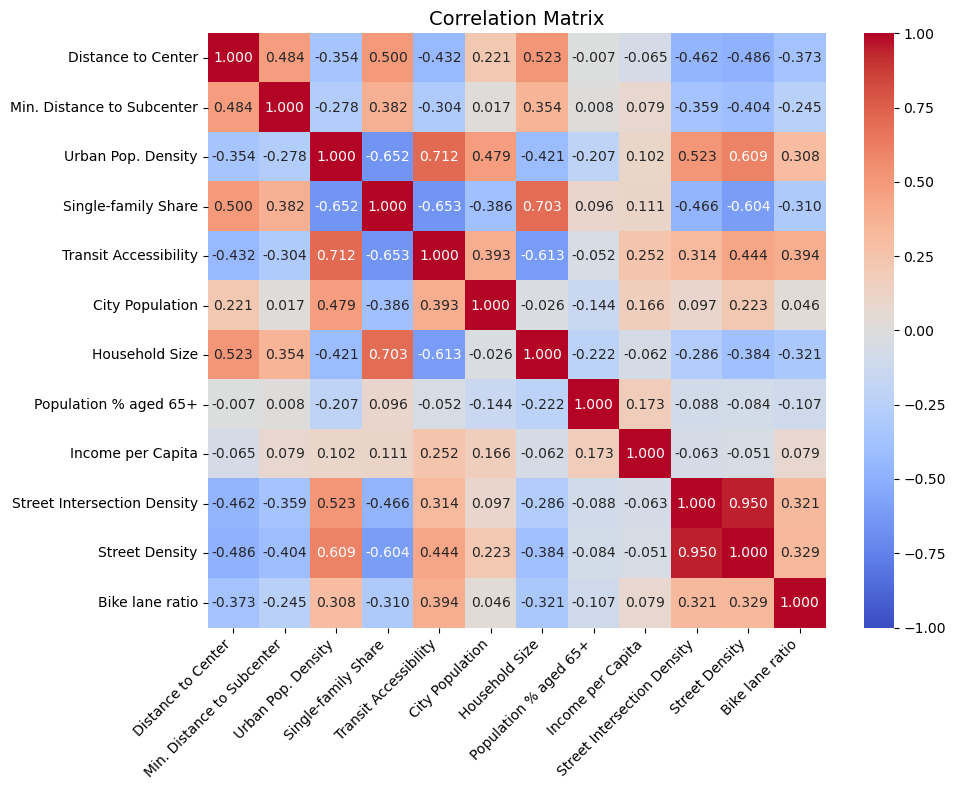

In [ ]:
corr_renamed = corr.rename(index=variable_labels_3, columns=variable_labels_3)

fig, ax = plt.subplots(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(
    corr_renamed, 
    annot=True,              # prints the values in the cells
    fmt=".3f",               # 3 decimal places
    cmap='coolwarm',         # color gradient
    vmin=-1, vmax=1,         # anchors the scale for correlations
    cbar=True,
    ax=ax
)

plt.title("Correlation Matrix", fontsize=14)
# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save
plt.savefig('datapaper_outputs/figures/corrs_heatmap.png', dpi=300, facecolor='white')
plt.show()

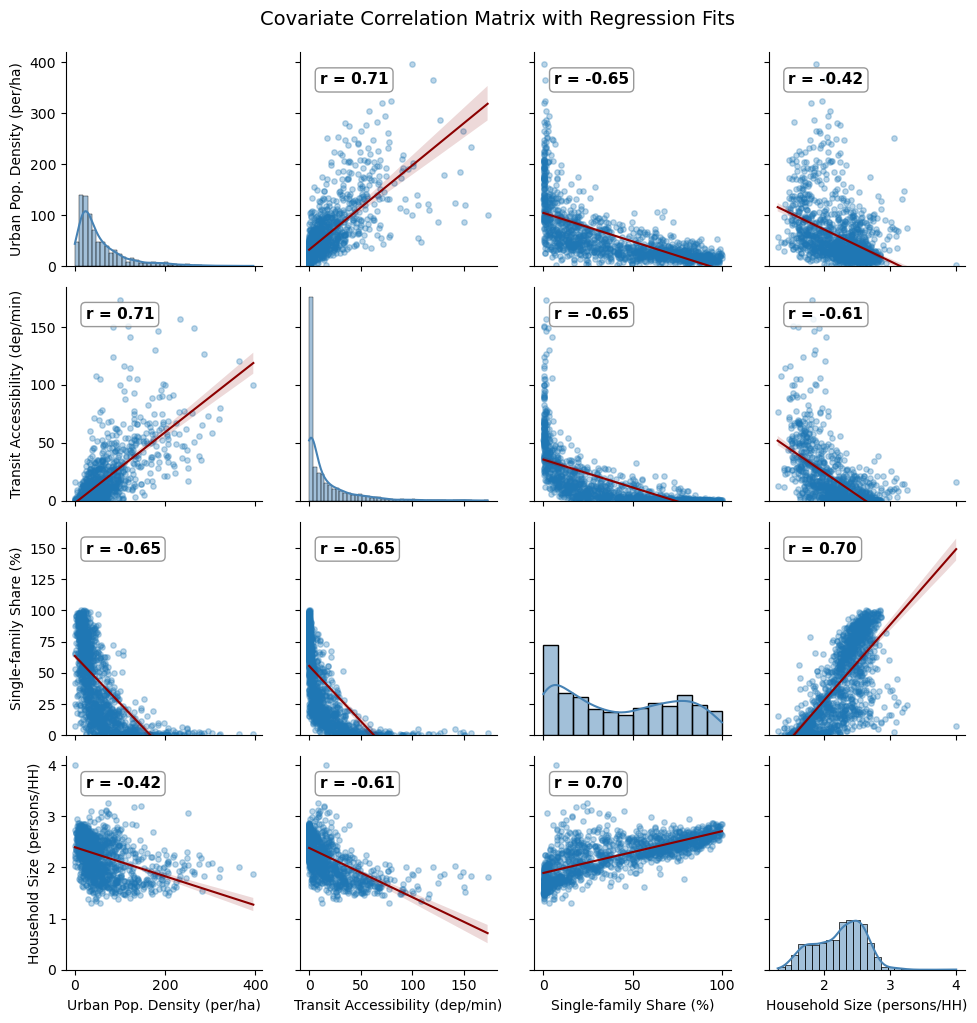

In [ ]:
# Define custom function to print r and p-value on each panel
def annotate_corr(x, y, ax=None, **kws):
    ax = ax or plt.gca()
    r, p = stats.pearsonr(x, y)

    ax.annotate(f'r = {r:.2f}', 
                xy=(0.1, 0.85), xycoords='axes fraction',
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8))

# 1. Select variables and rename headers
covariates = ['Urban Pop. Density', 'Transit Accessibility', 'Single-family Share', 'HH_size']
df_plot = df_reg[covariates].rename(columns=variable_labels)

# 2. Initialize PairGrid
g = sns.PairGrid(df_plot, corner=False) # Set corner=True if you only want the lower triangle

# 3. Map plot types
g.map_diag(sns.histplot, kde=True, kde_kws={'clip': (0, None)}, color='steelblue')
g.map_offdiag(sns.regplot, scatter_kws={'alpha': 0.3, 's': 15}, line_kws={'color': 'darkred', 'lw': 1.5})
g.map_offdiag(annotate_corr)

# 4. Enforce y-axis bottom bound at 0 across all subplots
for ax in g.axes.flatten():
    if ax is not None:
        ax.set_ylim(bottom=0)

g.fig.suptitle("Covariate Correlation Matrix with Regression Fits", y=1.02, fontsize=14)
plt.savefig('datapaper_outputs/figures/covariate_pairgrid_annotated.png', dpi=300, bbox_inches='tight')
plt.show()

remove street density and repeat

In [18]:
X.drop(columns='street_density',inplace=True)
df_reg.drop(columns='street_density',inplace=True)
continuous_x.remove('street_density')
x_vars.remove('street_density')


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [19]:
X_selc = add_constant(X)
vif2=pd.Series([variance_inflation_factor(X_selc.values, i) for i in range(X_selc.shape[1])], index=X_selc.columns)
vif2=vif2.to_frame().reset_index()
vif2.columns=['Feature','VIF']
corr = X.corr()
print(vif2)
corr.style.format(precision=3).background_gradient(cmap='coolwarm')

                   Feature         VIF
0                    const  157.872812
1       Distance to Center    2.558992
2   Min. dist to Subcenter    1.401013
3       Urban Pop. Density    3.135815
4      Single-family Share    4.749769
5    Transit Accessibility    3.358508
6          City Population    2.520320
7                  HH_size    3.439888
8                share_65+    1.326029
9              Inc_cap_std    1.439550
10        intersec_density    1.773770
11         bike_lane_ratio    1.321441


,Distance to Center,Min. dist to Subcenter,Urban Pop. Density,Single-family Share,Transit Accessibility,City Population,HH_size,share_65+,Inc_cap_std,intersec_density,bike_lane_ratio
Distance to Center,1.000,0.484,-0.354,0.500,-0.432,0.221,0.523,-0.007,-0.065,-0.462,-0.373
Min. dist to Subcenter,0.484,1.000,-0.278,0.382,-0.304,0.017,0.354,0.008,0.079,-0.359,-0.245
Urban Pop. Density,-0.354,-0.278,1.000,-0.652,0.712,0.479,-0.421,-0.207,0.102,0.523,0.308
Single-family Share,0.500,0.382,-0.652,1.000,-0.653,-0.386,0.703,0.096,0.111,-0.466,-0.310
Transit Accessibility,-0.432,-0.304,0.712,-0.653,1.000,0.393,-0.613,-0.052,0.252,0.314,0.394
City Population,0.221,0.017,0.479,-0.386,0.393,1.000,-0.026,-0.144,0.166,0.097,0.046
HH_size,0.523,0.354,-0.421,0.703,-0.613,-0.026,1.000,-0.222,-0.062,-0.286,-0.321
share_65+,-0.007,0.008,-0.207,0.096,-0.052,-0.144,-0.222,1.000,0.173,-0.088,-0.107
Inc_cap_std,-0.065,0.079,0.102,0.111,0.252,0.166,-0.062,0.173,1.000,-0.063,0.079
intersec_density,-0.462,-0.359,0.523,-0.466,0.314,0.097,-0.286,-0.088,-0.063,1.000,0.321


In [20]:
vif2.rename(columns={'VIF':'VIF 2'},inplace=True)

In [21]:
# do a third time without TA and HH_size
X_sens=X.copy()
X_sens.drop(columns=['Transit Accessibility','HH_size'],inplace=True)


X_selc = add_constant(X_sens)
vif3=pd.Series([variance_inflation_factor(X_selc.values, i) for i in range(X_selc.shape[1])], index=X_selc.columns)
vif3=vif3.to_frame().reset_index()
vif3.columns=['Feature','VIF 3']
print(vif3)

                  Feature      VIF 3
0                   const  41.697983
1      Distance to Center   2.513063
2  Min. dist to Subcenter   1.391767
3      Urban Pop. Density   2.486870
4     Single-family Share   2.729507
5         City Population   2.130939
6               share_65+   1.123519
7             Inc_cap_std   1.304335
8        intersec_density   1.650315
9         bike_lane_ratio   1.247247


In [22]:
vif_comp=round(vif.merge(vif2,how='left').merge(vif3,how='left'),3)
vif_comp.to_csv("datapaper_outputs/vif_comp.csv",index=False)
vif_comp

,Feature,VIF,VIF 2,VIF 3
0,const,170.463,157.873,41.698
1,Distance to Center,2.561,2.559,2.513
2,Min. dist to Subcenter,1.417,1.401,1.392
3,Urban Pop. Density,3.137,3.136,2.487
4,Single-family Share,5.066,4.750,2.730
5,Transit Accessibility,3.441,3.359,NaN
6,City Population,2.621,2.520,2.131
7,HH_size,3.441,3.440,NaN
8,share_65+,1.332,1.326,1.124
9,Inc_cap_std,1.441,1.440,1.304


run OLS with scaled continuous variables

In [24]:
continuous_x

['Distance to Center',
 'Min. dist to Subcenter',
 'Urban Pop. Density',
 'Single-family Share',
 'Transit Accessibility',
 'City Population',
 'HH_size',
 'share_65+',
 'Inc_cap_std',
 'intersec_density',
 'bike_lane_ratio']

In [25]:
continuous_x.remove('Inc_cap_std')


In [26]:
continuous_x

['Distance to Center',
 'Min. dist to Subcenter',
 'Urban Pop. Density',
 'Single-family Share',
 'Transit Accessibility',
 'City Population',
 'HH_size',
 'share_65+',
 'intersec_density',
 'bike_lane_ratio']

In [27]:
scaler = StandardScaler()
df_reg_std = df_reg.copy()
df_reg_std[continuous_x] = scaler.fit_transform(df_reg[continuous_x])

def run_model(df, x_vars, y_var):

    X = df[x_vars]
    X = sm.add_constant(X)
    y = df[y_var]
    model = sm.OLS(y, X).fit()

    # Extract key regression results
    results_df = pd.DataFrame({
        "coef": model.params,
        "std_err": model.bse,
        "t_value": model.tvalues,
        "p_value": model.pvalues
    })

    # Add model-level stats
    model_stats = pd.DataFrame({
        "R_squared": [model.rsquared],
        "Adj_R_squared": [model.rsquared_adj],
        "AIC": [model.aic],
        "BIC": [model.bic]
    })
    fn=re.sub(r"[ /]","_","regression_output_" + y_var + ".xlsx")
    # Save both to Excel
    with pd.ExcelWriter("datapaper_outputs/" + fn) as writer:

        results_df.to_excel(writer, sheet_name="coefficients")
        model_stats.to_excel(writer, sheet_name="model_stats")

    return model

models = {}

for y in y_vars:
    models[y] = run_model(df_reg_std, x_vars, y)


In [32]:
df_reg_std_DE=df_reg_std.loc[df_reg_std['Country_France']==0,]
df_reg_std_FR=df_reg_std.loc[df_reg_std['Country_France']==1,]

df_reg_std_DE.drop(columns='Country_France',inplace=True)
df_reg_std_FR.drop(columns='Country_France',inplace=True)

x_vars_country=x_vars.copy()
x_vars_country.remove('Country_France')


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [33]:
models_DE = {}
models_FR = {}

for y in y_vars:
    models_DE[y] = run_model(df_reg_std_DE, x_vars_country, y)

for y in y_vars:
    models_FR[y] = run_model(df_reg_std_FR, x_vars_country, y)

In [34]:
df_reg_sens=df_reg_std.copy()
df_reg_sens.drop(columns=['Transit Accessibility','HH_size'],inplace=True)
x_vars_sens=x_vars.copy()
x_vars_sens.remove('Transit Accessibility')
x_vars_sens.remove('HH_size')

models_sens={}
for y in y_vars:
    models_sens[y] = run_model(df_reg_sens, x_vars_sens, y)


In [ ]:
def collect_regression_results(models, x_vars):
    """
    models: dict of {y_var: fitted statsmodels OLS model}
    x_vars: list of X variable names (in desired row order)
    """
    # Start table with X variable names
    results = pd.DataFrame({"variable": ["const"] + x_vars})
    results = results.set_index("variable")

    # Loop through each model (each Y variable)
    for y, model in models.items():
        # Extract coefficient table
        coef = model.params
        se = model.bse
        pval = model.pvalues
        r2 = model.rsquared

        # Add 3 columns for this Y variable
        results[f"{y}_coef"] = coef
        results[f"{y}_se"] = se
        results[f"{y}_pval"] = pval

        # Add R² as a single value (same for all rows)
        results[f"{y}_R2"] = r2

    return results
results_table = collect_regression_results(models, x_vars)
results_table.to_csv("datapaper_outputs/all_regression_results_rev.csv")


In [ ]:
results_table_DE = collect_regression_results(models_DE, x_vars_country)
results_table_DE.to_csv("datapaper_outputs/all_regression_results_DE.csv")

results_table_FR = collect_regression_results(models_FR, x_vars_country)
results_table_FR.to_csv("datapaper_outputs/all_regression_results_FR.csv")

In [ ]:
results_table_sens=collect_regression_results(models_sens, x_vars_sens)
results_table_sens.to_csv("datapaper_outputs/all_regression_results_sens.csv")

In [ ]:
### now the machine learning models, ANN and GBDT

In [42]:
np.int = int
np.bool = bool
np.float=float

In [43]:
x_vars

['Distance to Center',
 'Min. dist to Subcenter',
 'Urban Pop. Density',
 'Single-family Share',
 'Transit Accessibility',
 'City Population',
 'Country_France',
 'HH_size',
 'share_65+',
 'Inc_cap_std',
 'intersec_density',
 'bike_lane_ratio']

In [44]:
# updated ML pipeline: GBDT

# 1. Single Train/Test Split (stratified or grouped by city if available)
# If using spatial grouping, hold out full cities using GroupShuffleSplit
X = df_reg_std[x_vars] 

# 2. Comprehensive Search Grid (All combinations = 48 fits)
gbdt_param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "colsample_bytree": [0.7]
}

gbdt_models = {}
gbdt_results = []

for y in y_vars:
    y_data = df_reg_std[y]
    
    # Stratified/Clean Train-Test Split per outcome
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_data, test_size=0.2, random_state=42
    )

    model = XGBRegressor(random_state=42, n_jobs=1)

    # Use GridSearchCV since parameter space is small (36 combinations)
    search = GridSearchCV(
        estimator=model,
        param_grid=gbdt_param_grid,
        cv=5,                       # Consider cv=GroupKFold() if grouping by city
        scoring="r2",
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    # Store best estimator
    best_model = search.best_estimator_
    gbdt_models[y] = best_model

    # Evaluate on held-out test set
    y_pred = best_model.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = mean_squared_error(y_test, y_pred, squared=False)

    gbdt_results.append({
        'outcome': y,
        'best_params': search.best_params_,
        'cv_best_r2': search.best_score_,
        'test_r2': test_r2,
        'test_rmse': test_rmse
    })

# Convert summary results to DataFrame
df_gbdt_performance = pd.DataFrame(gbdt_results)
print(df_gbdt_performance)



pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.


            outcome                                        best_params  \
0      p-km/cap car  {'colsample_bytree': 0.7, 'learning_rate': 0.0...   
1  p-km/cap transit  {'colsample_bytree': 0.7, 'learning_rate': 0.0...   
2           Car/cap  {'colsample_bytree': 0.7, 'learning_rate': 0.0...   
3  Mobility CO2/cap  {'colsample_bytree': 0.7, 'learning_rate': 0.0...   

   cv_best_r2   test_r2    test_rmse  
0    0.681966  0.590350  1800.025562  
1    0.340242  0.222160   806.956071  
2    0.630151  0.590069     0.106355  
3    0.698378  0.606030     0.384252  


In [46]:
# gbdt sensitivity

X_sens=X.copy()
X_sens.drop(columns=['Transit Accessibility','HH_size'],inplace=True)

gbdt_sens_models = {}
gbdt_sens_results = []

for y in y_vars:
    y_data = df_reg_std[y]
    
    # Stratified/Clean Train-Test Split per outcome
    X_train_sens, X_test_sens, y_train, y_test = train_test_split(
        X_sens, y_data, test_size=0.2, random_state=42
    )

    model = XGBRegressor(random_state=42, n_jobs=1)

    # Use GridSearchCV since parameter space is small (36 combinations)
    search = GridSearchCV(
        estimator=model,
        param_grid=gbdt_param_grid,
        cv=5,                       # Consider cv=GroupKFold() if grouping by city
        scoring="r2",
        n_jobs=-1
    )

    search.fit(X_train_sens, y_train)

    # Store best estimator
    best_model = search.best_estimator_
    gbdt_sens_models[y] = best_model

    # Evaluate on held-out test set
    y_pred = best_model.predict(X_test_sens)
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = mean_squared_error(y_test, y_pred, squared=False)

    gbdt_sens_results.append({
        'outcome': y,
        'best_params': search.best_params_,
        'cv_best_r2': search.best_score_,
        'test_r2': test_r2,
        'test_rmse': test_rmse
    })

# Convert summary results to DataFrame
df_gbdt_sens_performance = pd.DataFrame(gbdt_sens_results)
print(df_gbdt_sens_performance)

pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.


            outcome                                        best_params  \
0      p-km/cap car  {'colsample_bytree': 0.7, 'learning_rate': 0.0...   
1  p-km/cap transit  {'colsample_bytree': 0.7, 'learning_rate': 0.0...   
2           Car/cap  {'colsample_bytree': 0.7, 'learning_rate': 0.0...   
3  Mobility CO2/cap  {'colsample_bytree': 0.7, 'learning_rate': 0.0...   

   cv_best_r2   test_r2    test_rmse  
0    0.686770  0.585542  1810.558156  
1    0.331918  0.224483   805.750667  
2    0.627764  0.599102     0.105176  
3    0.707401  0.589261     0.392344  


In [47]:
# new new ANN 

# 1. Define your original model as the base estimator
base_ann = MLPRegressor(
    activation='relu', 
    solver='adam', 
    max_iter=2000, 
    random_state=42
)

# 2. Wrap it in a BaggingRegressor
model = BaggingRegressor(
    estimator=base_ann,
    n_estimators=10,    # Trains 10 ANNs and averages their predictions
    max_features=0.7,   # THE EQUIVALENT OF colsample_bytree=0.7
    random_state=42
)

# 3. Add the 'estimator__' prefix to your grid search parameters
ann_param_grid = {
    "estimator__hidden_layer_sizes": [(32,16), (64,32), (64,64)],
    "estimator__alpha": [0.0001, 0.001, 0.01],
    "estimator__learning_rate_init": [0.001, 0.01],
}

# The rest of your GridSearchCV code remains completely untouched.


ann_models = {}
ann_results = []

for y in y_vars:
    y_data = df_reg_std[y]
    
    # Train-Test Split matching GBDT
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_data, test_size=0.2, random_state=42
    )

    # Use GridSearchCV across all 18 parameter combinations
    search = GridSearchCV(
        estimator=model,
        param_grid=ann_param_grid,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    # Store best estimator
    best_model = search.best_estimator_
    ann_models[y] = best_model

    # Evaluate on held-out test set
    y_pred = best_model.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = mean_squared_error(y_test, y_pred, squared=False)

    ann_results.append({
        'outcome': y,
        'best_params': search.best_params_,
        'cv_best_r2': search.best_score_,
        'test_r2': test_r2,
        'test_rmse': test_rmse
    })

# Summary results DataFrame
df_ann_performance = pd.DataFrame(ann_results)
print(df_ann_performance)



            outcome                                        best_params  \
0      p-km/cap car  {'estimator__alpha': 0.0001, 'estimator__hidde...   
1  p-km/cap transit  {'estimator__alpha': 0.001, 'estimator__hidden...   
2           Car/cap  {'estimator__alpha': 0.01, 'estimator__hidden_...   
3  Mobility CO2/cap  {'estimator__alpha': 0.0001, 'estimator__hidde...   

   cv_best_r2   test_r2    test_rmse  
0    0.701912  0.613415  1748.618248  
1    0.349038  0.298803   766.169697  
2    0.637785  0.575008     0.108291  
3    0.724198  0.613651     0.380517  


In [48]:
# ANN sens new

# 1. Define your original model as the base estimator
base_ann = MLPRegressor(
    activation='relu', 
    solver='adam', 
    max_iter=2000, 
    random_state=42
)

# 2. Wrap it in a BaggingRegressor
model = BaggingRegressor(
    estimator=base_ann,
    n_estimators=10,    # Trains 10 ANNs and averages their predictions
    max_features=0.7,   # THE EQUIVALENT OF colsample_bytree=0.7
    random_state=42
)

# 3. Add the 'estimator__' prefix to your grid search parameters
ann_param_grid = {
    "estimator__hidden_layer_sizes": [(32,16), (64,32), (64,64)],
    "estimator__alpha": [0.0001, 0.001, 0.01],
    "estimator__learning_rate_init": [0.001, 0.01],
}

ann_sens_models = {}
ann_sens_results = []

for y in y_vars:
    y_data = df_reg_std[y]
    
    # Train-Test Split matching GBDT
    X_train_sens, X_test_sens, y_train, y_test = train_test_split(
        X_sens, y_data, test_size=0.2, random_state=42
    )

    # Use GridSearchCV across all 18 parameter combinations
    search = GridSearchCV(
        estimator=model,
        param_grid=ann_param_grid,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    search.fit(X_train_sens, y_train)

    # Store best estimator
    best_model = search.best_estimator_
    ann_sens_models[y] = best_model

    # Evaluate on held-out test set
    y_pred = best_model.predict(X_test_sens)
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = mean_squared_error(y_test, y_pred, squared=False)

    ann_sens_results.append({
        'outcome': y,
        'best_params': search.best_params_,
        'cv_best_r2': search.best_score_,
        'test_r2': test_r2,
        'test_rmse': test_rmse
    })

# Summary results DataFrame
df_ann_performance = pd.DataFrame(ann_sens_results)
print(df_ann_performance)


Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.


            outcome                                        best_params  \
0      p-km/cap car  {'estimator__alpha': 0.01, 'estimator__hidden_...   
1  p-km/cap transit  {'estimator__alpha': 0.01, 'estimator__hidden_...   
2           Car/cap  {'estimator__alpha': 0.01, 'estimator__hidden_...   
3  Mobility CO2/cap  {'estimator__alpha': 0.01, 'estimator__hidden_...   

   cv_best_r2   test_r2    test_rmse  
0    0.703136  0.615329  1744.283092  
1    0.344663  0.319596   754.724019  
2    0.642194  0.592440     0.106047  
3    0.723030  0.619499     0.377626  


In [49]:
df_ann_performance = pd.DataFrame(ann_results)
df_ann_performance['model']='ANN full'
df_ann_sens_performance = pd.DataFrame(ann_sens_results)
df_ann_sens_performance['model']='ANN sens'
df_gbdt_performance = pd.DataFrame(gbdt_results)
df_gbdt_performance['model']='GBDT full'
df_gbdt_sens_performance = pd.DataFrame(gbdt_sens_results)
df_gbdt_sens_performance['model']='GBDT sens'

ml_perf = pd.concat([df_ann_performance,df_ann_sens_performance,df_gbdt_performance,df_gbdt_sens_performance])
ml_perf

,outcome,best_params,cv_best_r2,test_r2,test_rmse,model
0,p-km/cap car,"{'estimator__alpha': 0.0001, 'estimator__hidde...",0.701912,0.613415,1748.618248,ANN full
1,p-km/cap transit,"{'estimator__alpha': 0.001, 'estimator__hidden...",0.349038,0.298803,766.169697,ANN full
2,Car/cap,"{'estimator__alpha': 0.01, 'estimator__hidden_...",0.637785,0.575008,0.108291,ANN full
3,Mobility CO2/cap,"{'estimator__alpha': 0.0001, 'estimator__hidde...",0.724198,0.613651,0.380517,ANN full
0,p-km/cap car,"{'estimator__alpha': 0.01, 'estimator__hidden_...",0.703136,0.615329,1744.283092,ANN sens
1,p-km/cap transit,"{'estimator__alpha': 0.01, 'estimator__hidden_...",0.344663,0.319596,754.724019,ANN sens
2,Car/cap,"{'estimator__alpha': 0.01, 'estimator__hidden_...",0.642194,0.592440,0.106047,ANN sens
3,Mobility CO2/cap,"{'estimator__alpha': 0.01, 'estimator__hidden_...",0.723030,0.619499,0.377626,ANN sens
0,p-km/cap car,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.681966,0.590350,1800.025562,GBDT full
1,p-km/cap transit,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.340242,0.222160,806.956071,GBDT full


In [ ]:
ml_perf.to_csv('datapaper_outputs/ML_comp_rev.csv',index=False)

In [ ]:
# shap analysis

# Store splits in separate dictionaries
splits_full = {}
splits_sens = {}

for y in y_vars:
    y_data = df_reg_std[y]
    
    # Splits for Full Model
    X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
        X, y_data, test_size=0.2, random_state=42
    )
    splits_full[y] = (X_tr_f, X_te_f, y_tr_f, y_te_f)

    # Splits for Sensitivity Model (Same random_state guarantees identical row selection)
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
        X_sens, y_data, test_size=0.2, random_state=42
    )
    splits_sens[y] = (X_tr_s, X_te_s, y_tr_s, y_te_s)

In [ ]:
shap.initjs()

gbdt_shap = {}

for y in y_vars:
    model = gbdt_models[y]
    X_train, X_test, y_train, y_test = splits_full[y]

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test)
    gbdt_shap[y] = (explainer, shap_values)

In [54]:
# --- Sensitivity GBDT SHAP ---
gbdt_shap_sens = {}
for y in y_vars:
    model = gbdt_sens_models[y]
    X_train, X_test, _, _ = splits_sens[y]  # Safe: Uses X_sens features

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test)
    gbdt_shap_sens[y] = (explainer, shap_values)

In [ ]:
ann_shap = {}

for y in y_vars:
    model = ann_models[y]
    X_train, X_test, y_train, y_test = splits_full[y]

    background = X_train.sample(100, random_state=42)

    explainer = shap.KernelExplainer(model.predict, background)

    # Use full X_test 
    shap_values = explainer.shap_values(X_test)

    ann_shap[y] = (explainer, shap_values)


In [ ]:
ann_shap_sens = {}

for y in y_vars:
    model = ann_sens_models[y]
    X_train, X_test, y_train, y_test = splits_sens[y]

    background = X_train.sample(100, random_state=42)

    explainer = shap.KernelExplainer(model.predict, background)

    # Use full X_test 
    shap_values = explainer.shap_values(X_test)

    ann_shap_sens[y] = (explainer, shap_values)

In [57]:
# subplots of shap scatter
x_subset = [
    'Urban Pop. Density',
    'Distance to Center',
    'Single-family Share',
    'Transit Accessibility'
]
x_subset_sens = [
    'Urban Pop. Density',
    'Distance to Center',
    'Single-family Share',
    'intersec_density'
]

x_subset_SI1=['City Population','Inc_cap_std','share_65+','HH_size']

In [ ]:
def plot_shap_grid(model_type,filename_suffix, shap_dict, splits, x_subset, y_vars):
    y_lab=''
    fig, axes = plt.subplots(len(y_vars), len(x_subset), figsize=(18, 15))
    fig.subplots_adjust(hspace=0.4, wspace=0.3)

    row_labels = ['a)','b)','c)','d)']
    label_idx = 0

    for i, y in enumerate(y_vars):
        explainer, shap_values = shap_dict[y]
        X_train, X_test, y_train, y_test = splits[y]

        # Use full X_test for both models
        X_test_used = X_test

        # Extract SHAP matrix
        if model_type == 'ann':
            shap_matrix = shap_values      # KernelExplainer output
        else:
            shap_matrix = shap_values.values  # TreeExplainer output

# ---- Add row label on the left side of the FIRST subplot in the row ---- 
        axes[i, 0].text(
            -0.25, 0.5, # position (left of the subplot)
            row_labels[i], # label
            transform=axes[i, 0].transAxes, 
            fontsize=14, 
            fontweight='bold', 
            va='center', 
            ha='right' )

        for j, x in enumerate(x_subset):
            ax = axes[i, j]

            idx = list(X_test_used.columns).index(x)

            shap_vec = shap_matrix[:, idx]
            x_vec = X_test_used.iloc[:, idx]
            #color_vec = X_test_used['Country_France']
            color_map = {0: "black", 1: "tab:orange"} 
            colors = X_test_used['Country_France'].map(color_map)

            ax.scatter(
                x_vec,
                shap_vec,
                c=colors,
                alpha=0.7,
                s=15
            )
            
            if y=='p-km/cap car':
                y_lab='car travel'
            if y=='p-km/cap transit':
                y_lab='transit travel'
            if y=='Car/cap':
                y_lab='car ownership'
            if y=='Mobility CO2/cap':
                y_lab='mobility emissions'

           # ax.set_title(f"{x} → {y_lab}", fontsize=10)
            ax.set_title(f"{y_lab}: SHAP of {variable_labels_3.get(x, x)}", fontsize=10)
            ax.set_xlabel(variable_labels_2.get(x, x), fontsize=12)
            ax.set_ylabel("SHAP value (" + y + ")" )
        # ---- Add legend for country colors ---- 
        legend_handles = [ plt.Line2D([0], [0], marker='o', color='none', markeredgecolor='none', markerfacecolor='black', markersize=8, label='Germany'),
                           plt.Line2D([0], [0], marker='o', color='none', markeredgecolor='none', markerfacecolor='tab:orange', markersize=8, label='France') ]
        fig.legend( handles=legend_handles, loc='upper center', ncol=2, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 1.01) )
    title_suffix = ''
    if filename_suffix =='_sens':
        title_suffix = ' (Sensitivity)'
    fig.suptitle('SHAP Analysis ' + model_type.upper() + ' Model' + title_suffix,fontsize=18, fontweight='bold', y=1.03)   # moves the title upward so it doesn't overlap the legend
    plt.tight_layout()
    
    fig.savefig('datapaper_outputs/figures/shap_' + model_type.upper() + filename_suffix + '.png',dpi=300,bbox_inches='tight')
    plt.show()


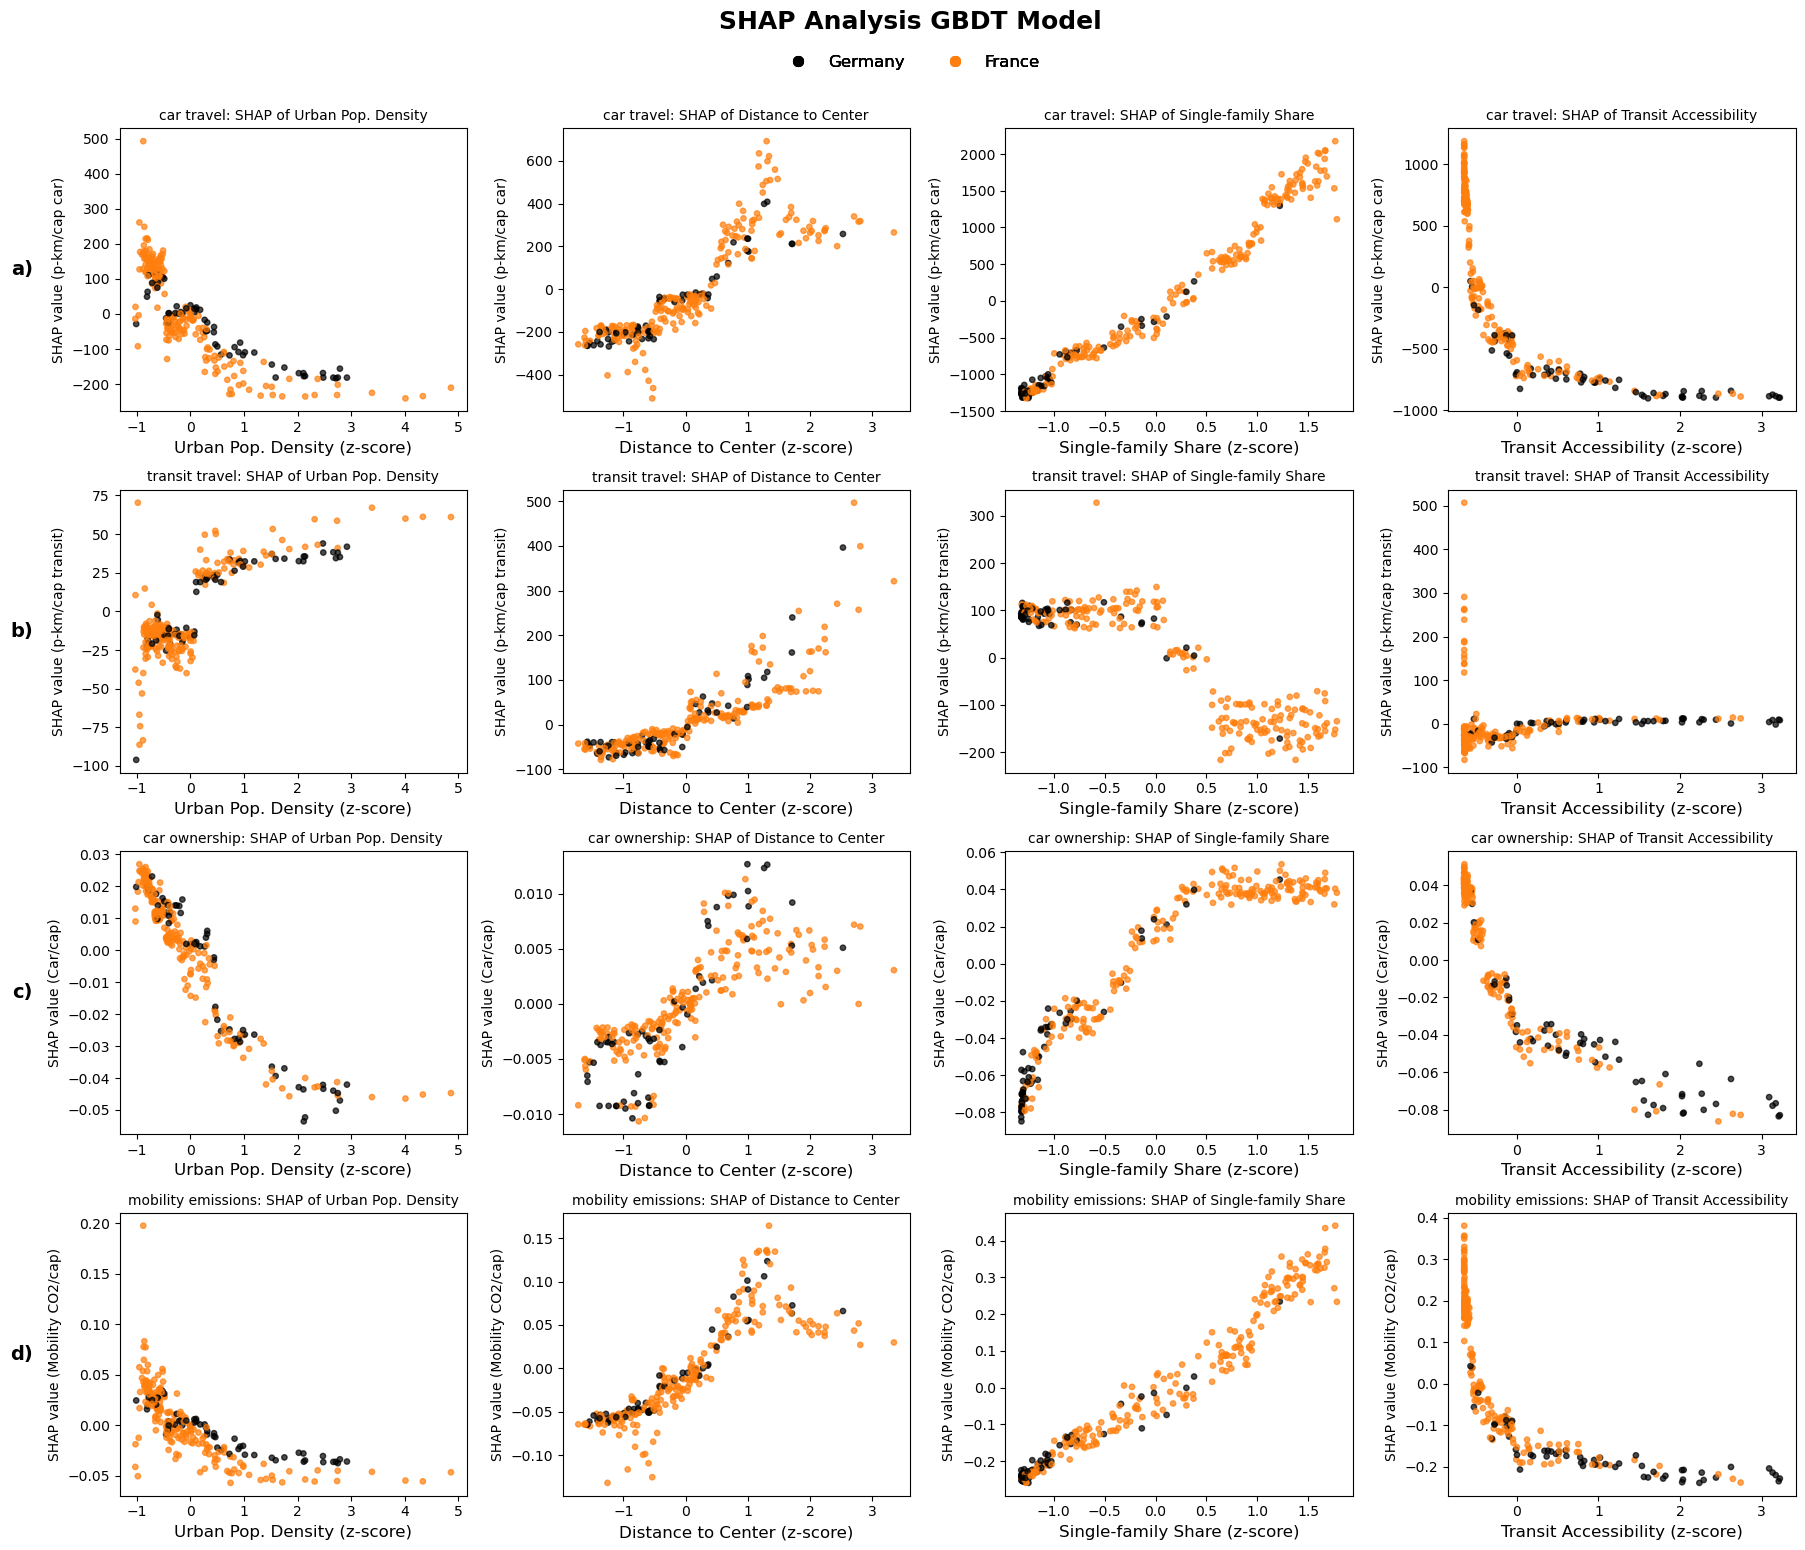

In [59]:
plot_shap_grid(
    model_type='gbdt',
    filename_suffix='',
    shap_dict=gbdt_shap,
    splits=splits_full,
    x_subset=x_subset,
    y_vars=y_vars
)

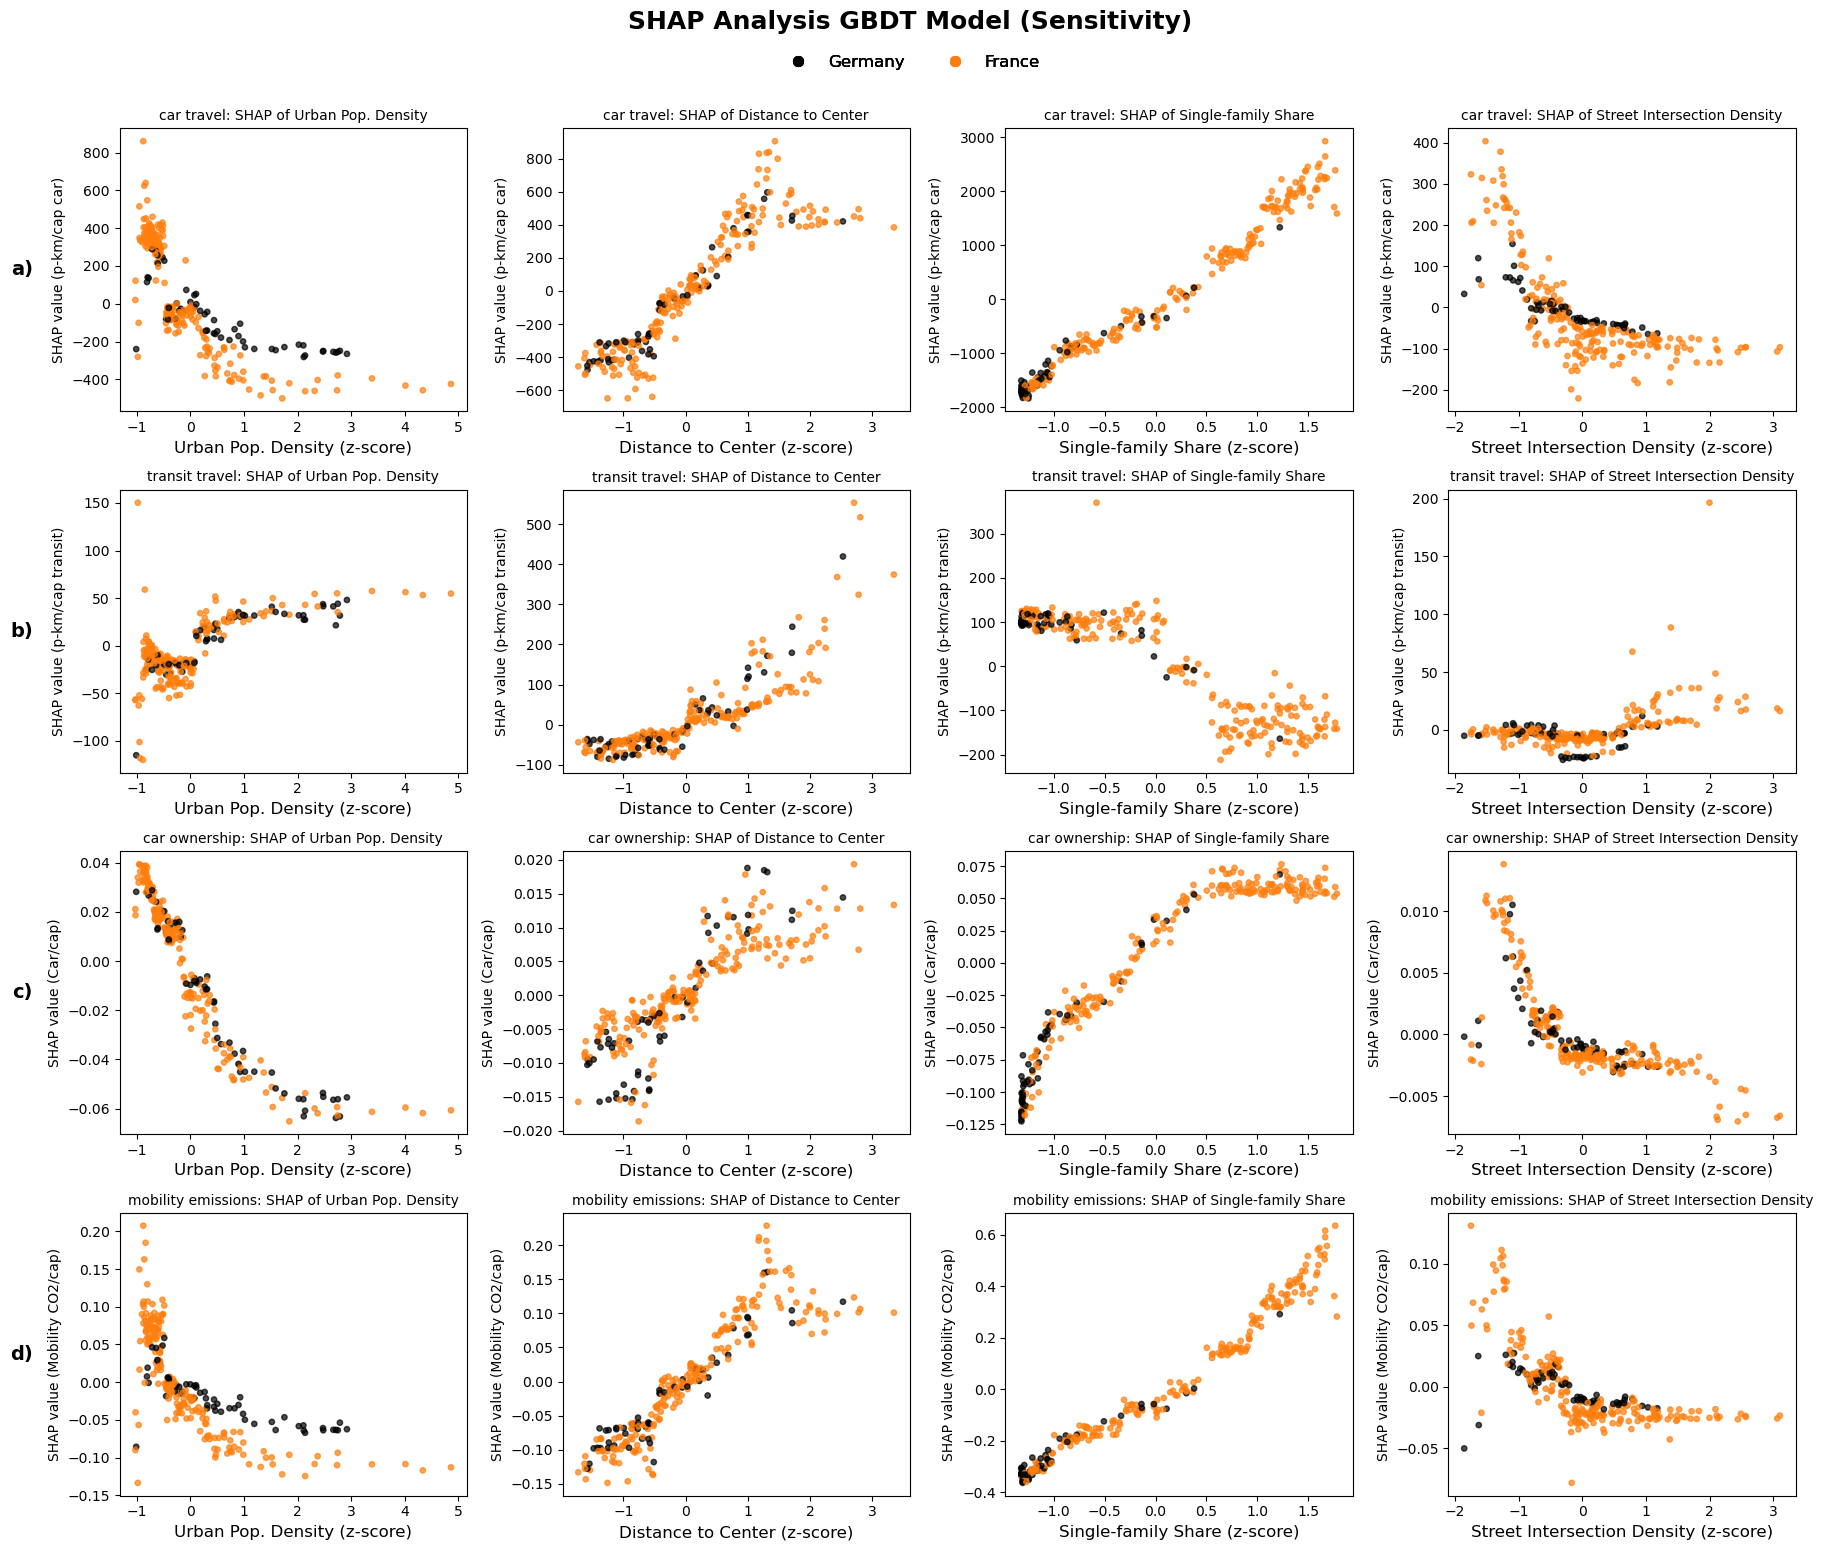

In [60]:
plot_shap_grid(
    model_type='gbdt',
    filename_suffix='_sens',
    shap_dict=gbdt_shap_sens,
    splits=splits_sens,
    x_subset=x_subset_sens,
    y_vars=y_vars
)

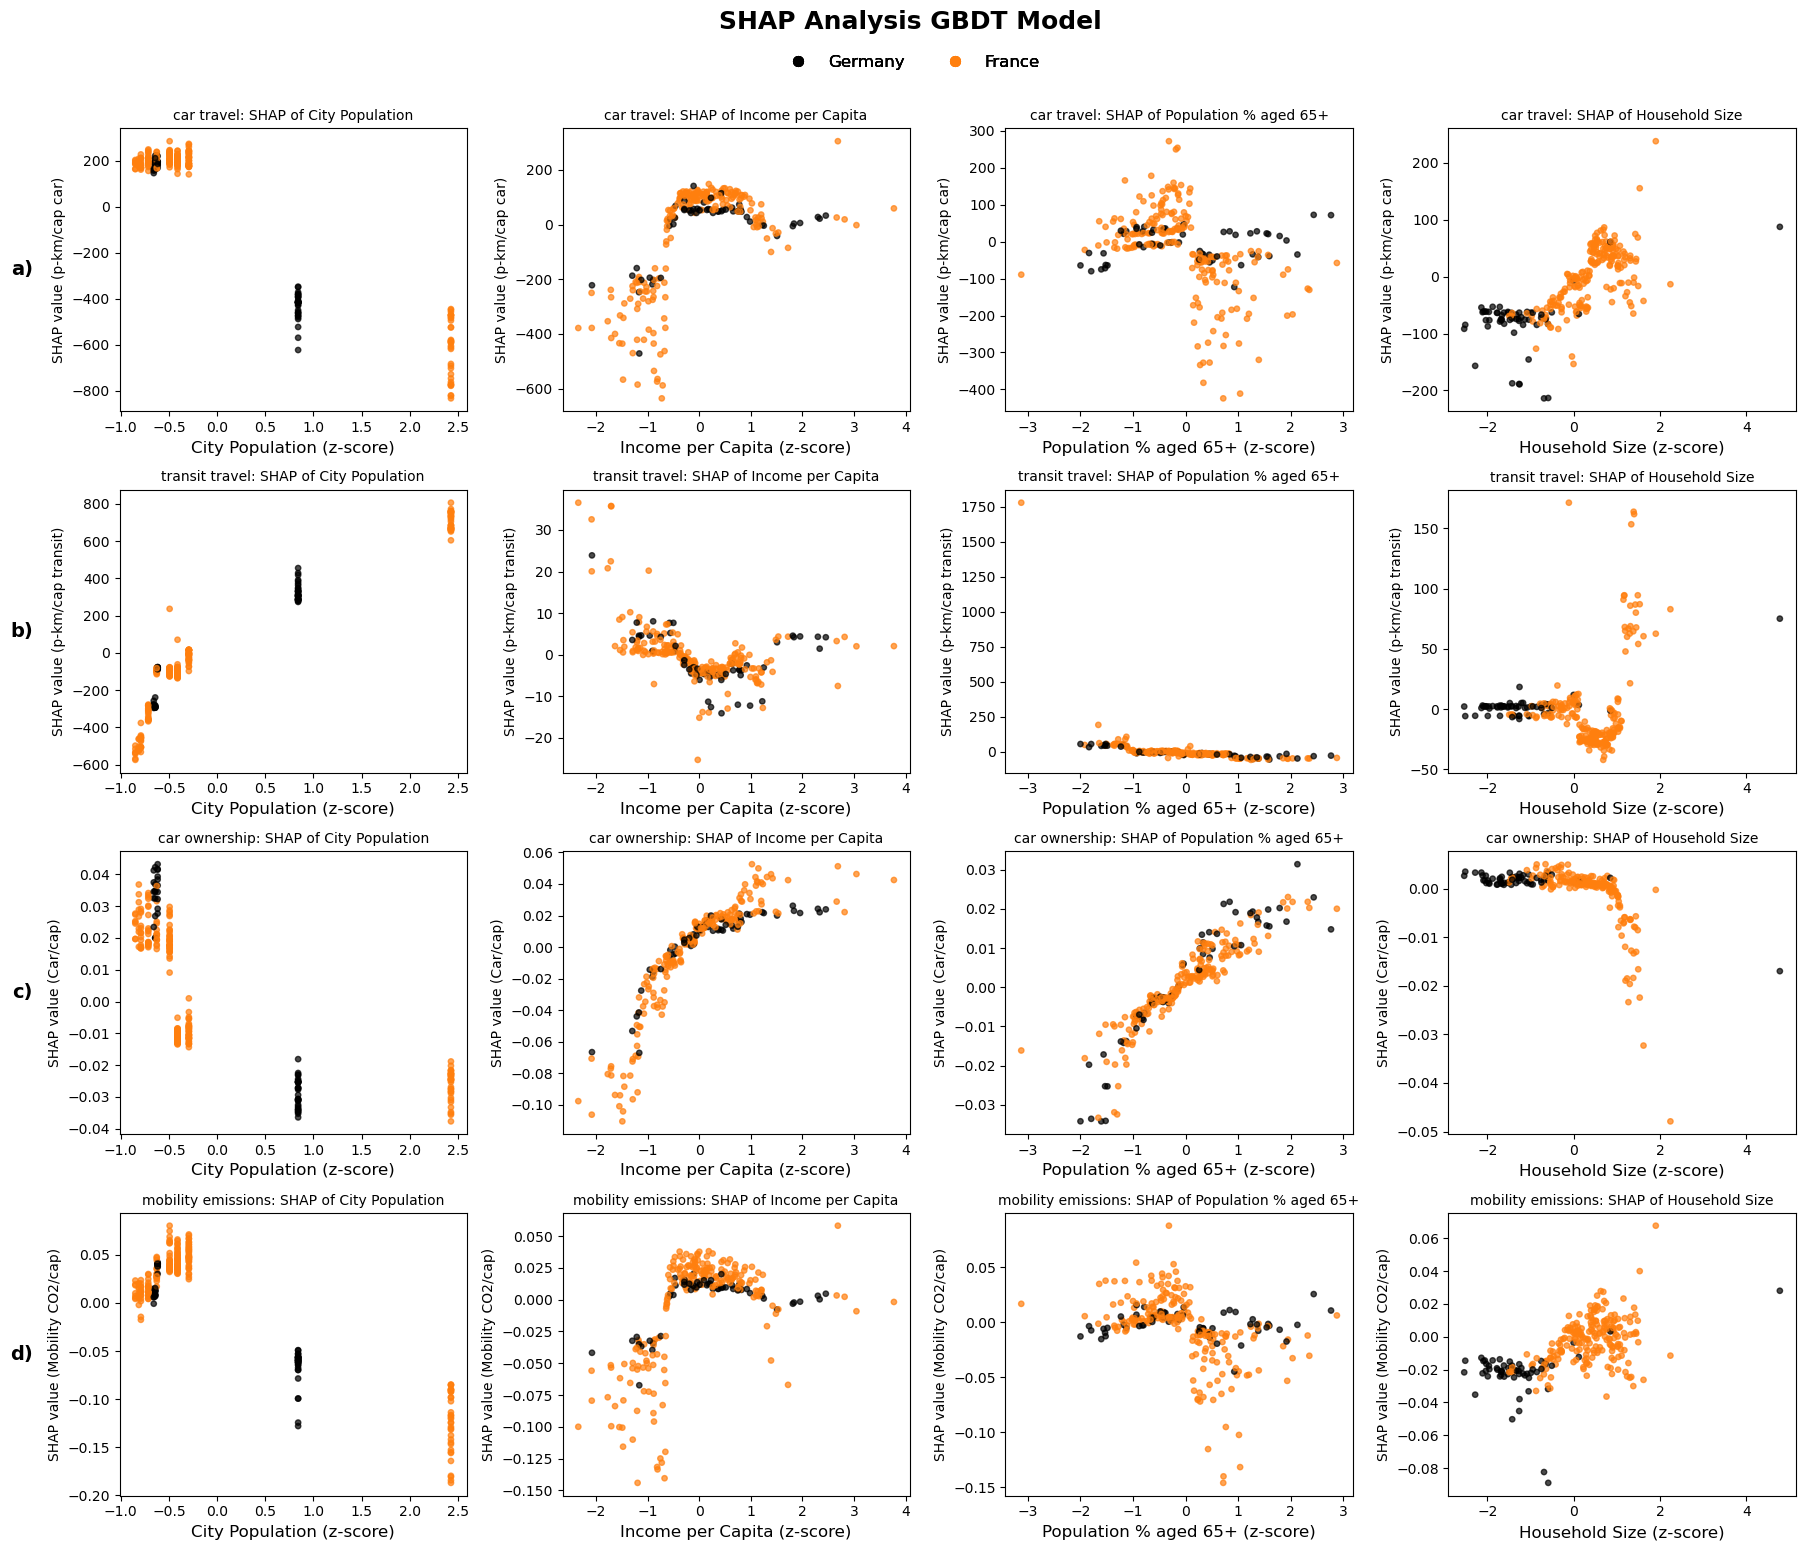

In [61]:
plot_shap_grid(
    model_type='gbdt',
    filename_suffix='_SI1',
    shap_dict=gbdt_shap,
    splits=splits_full,
    x_subset=x_subset_SI1,
    y_vars=y_vars
)

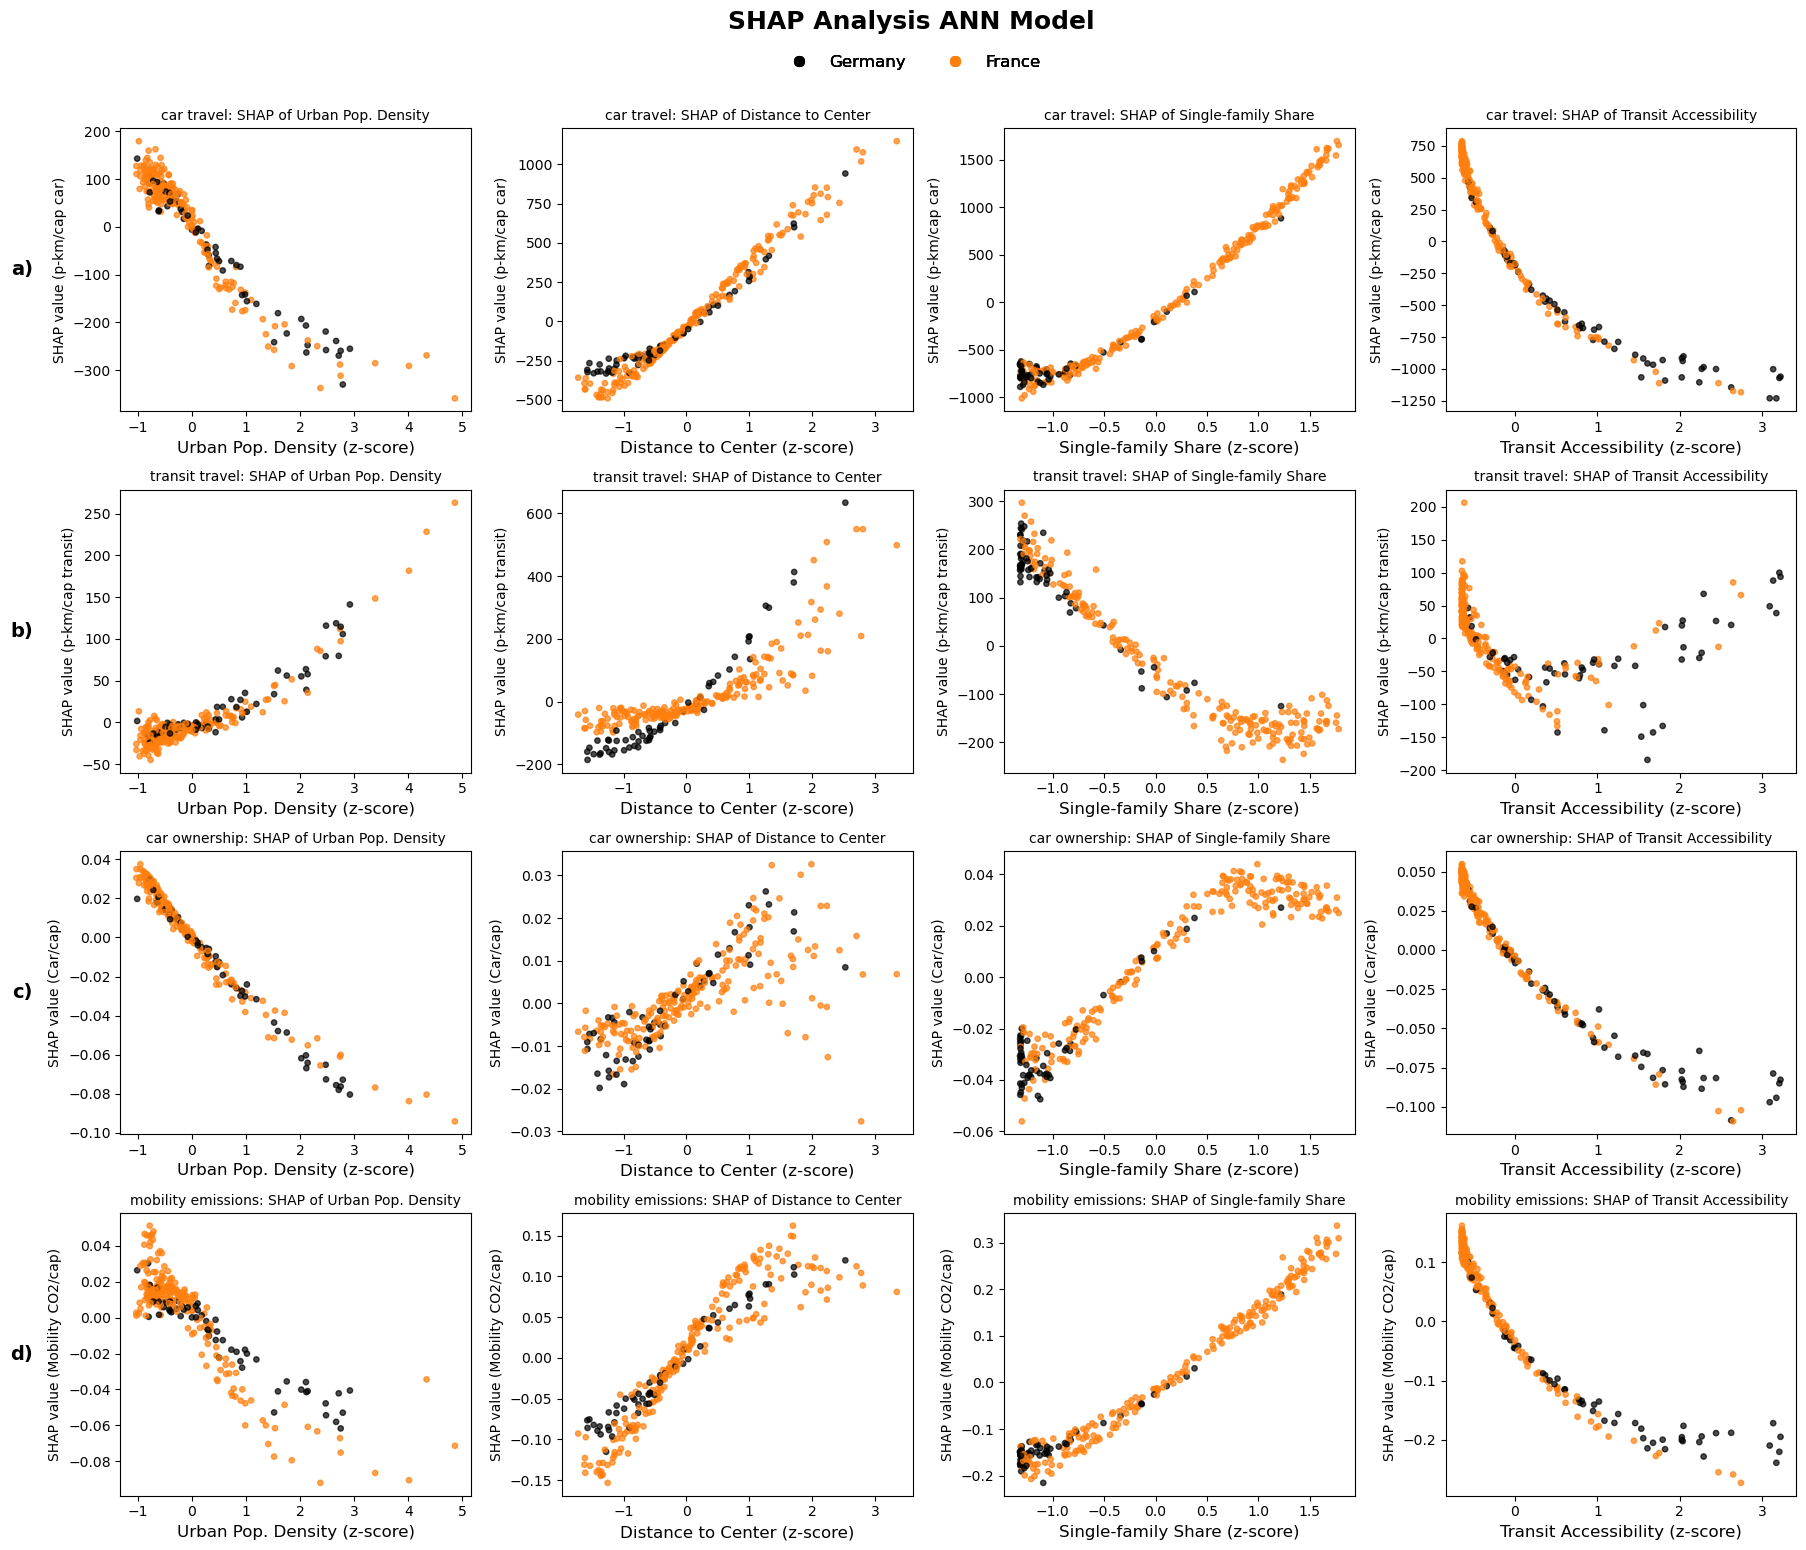

In [62]:
plot_shap_grid(
    model_type='ann',
    filename_suffix='',
    shap_dict=ann_shap,
    splits=splits_full,
    x_subset=x_subset,
    y_vars=y_vars
)

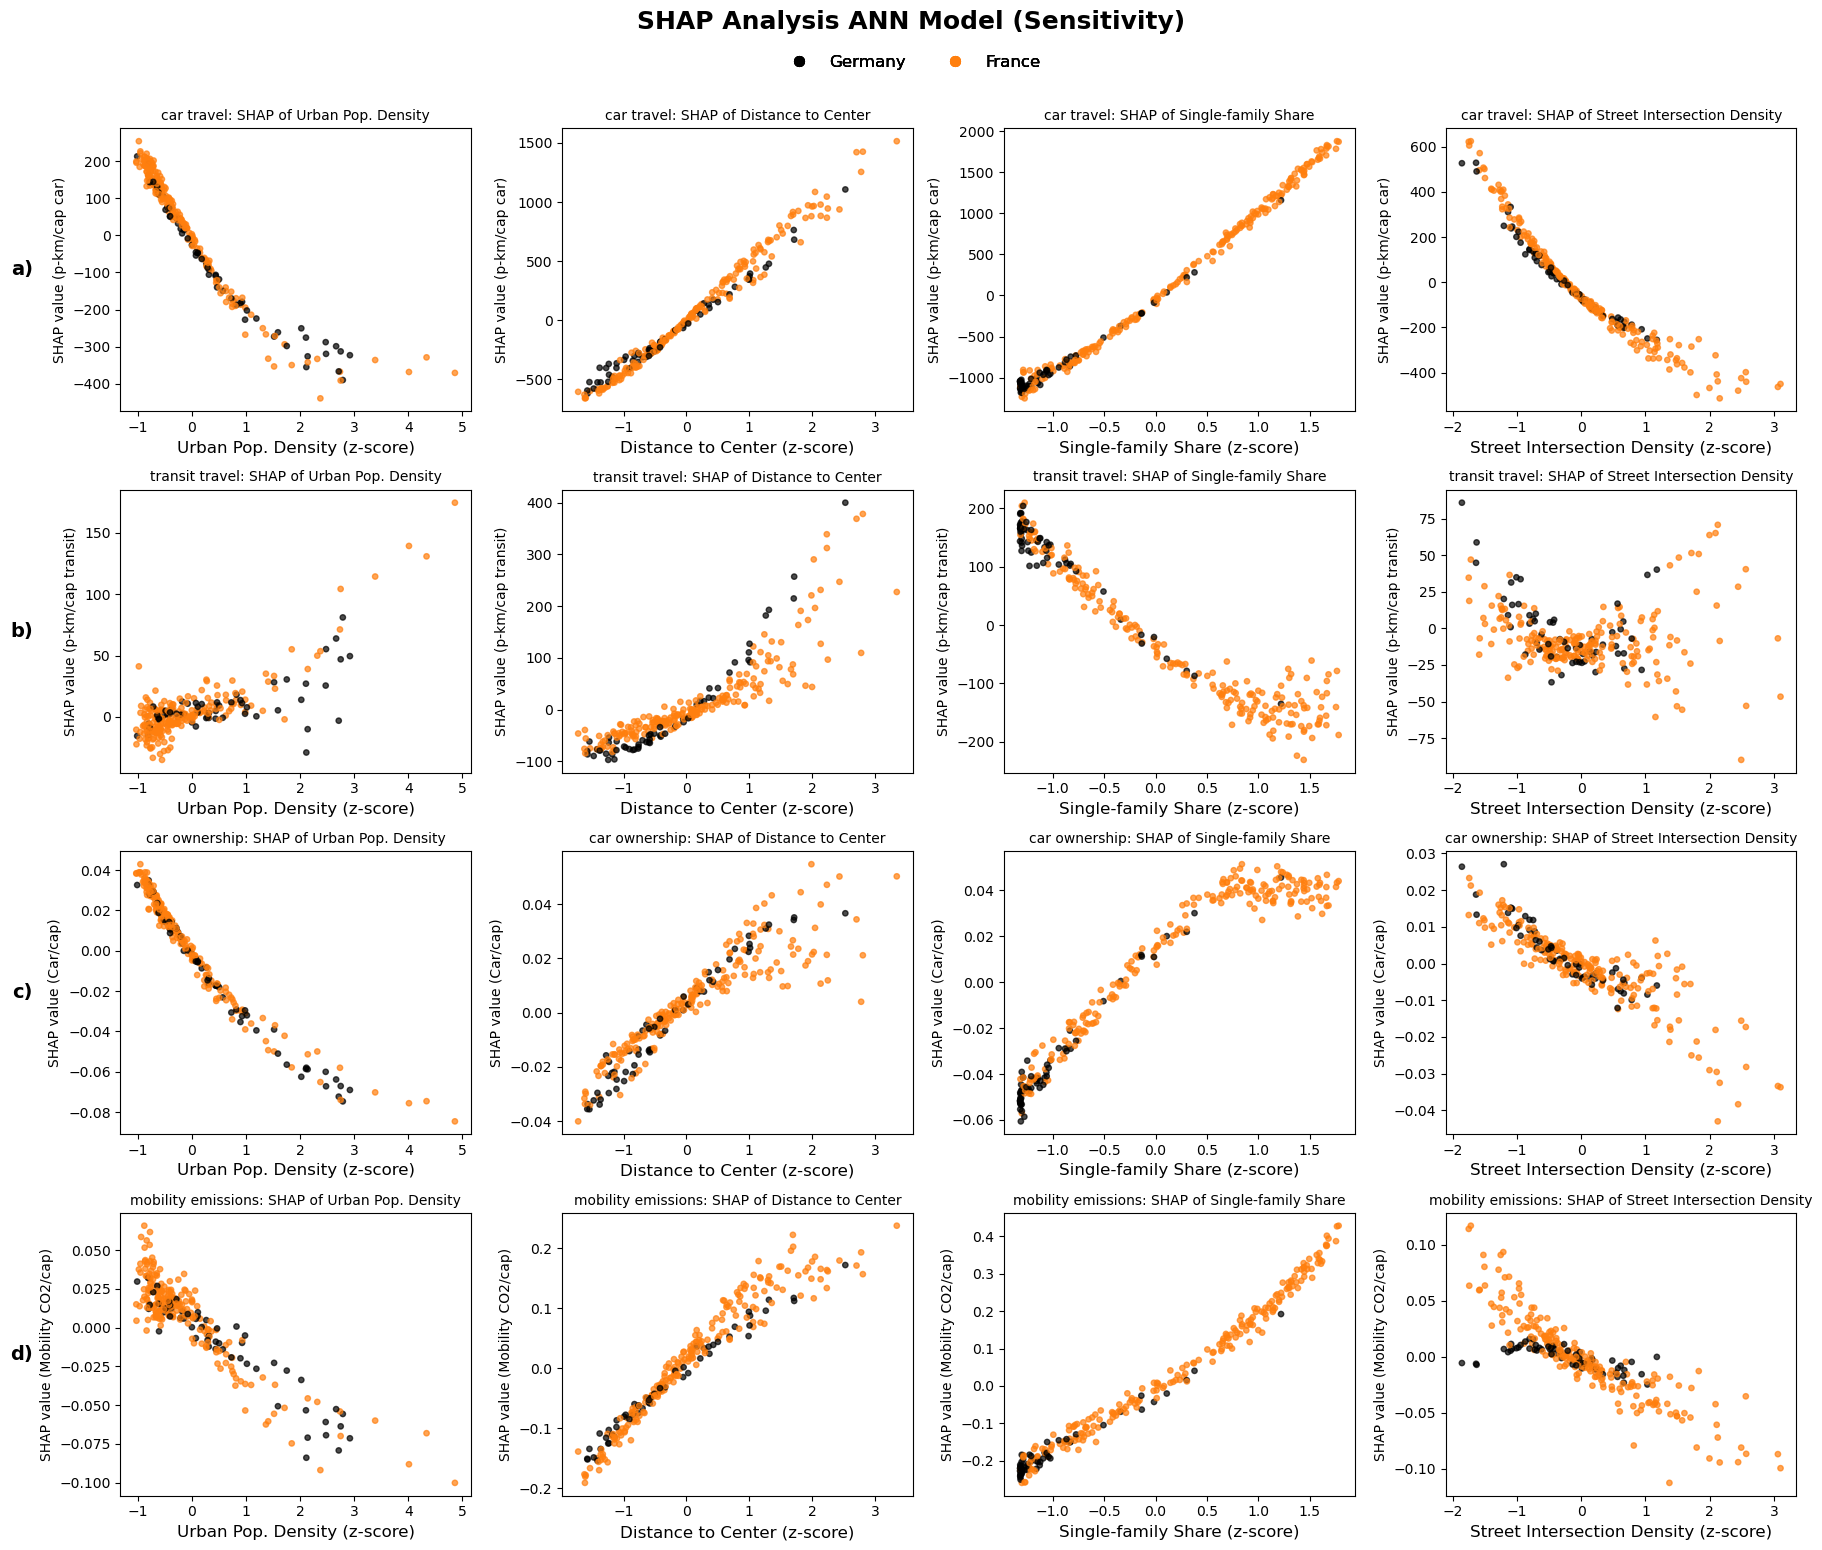

In [63]:
plot_shap_grid(
    model_type='ann',
    filename_suffix='_sens',
    shap_dict=ann_shap_sens,
    splits=splits_sens,
    x_subset=x_subset_sens,
    y_vars=y_vars
)

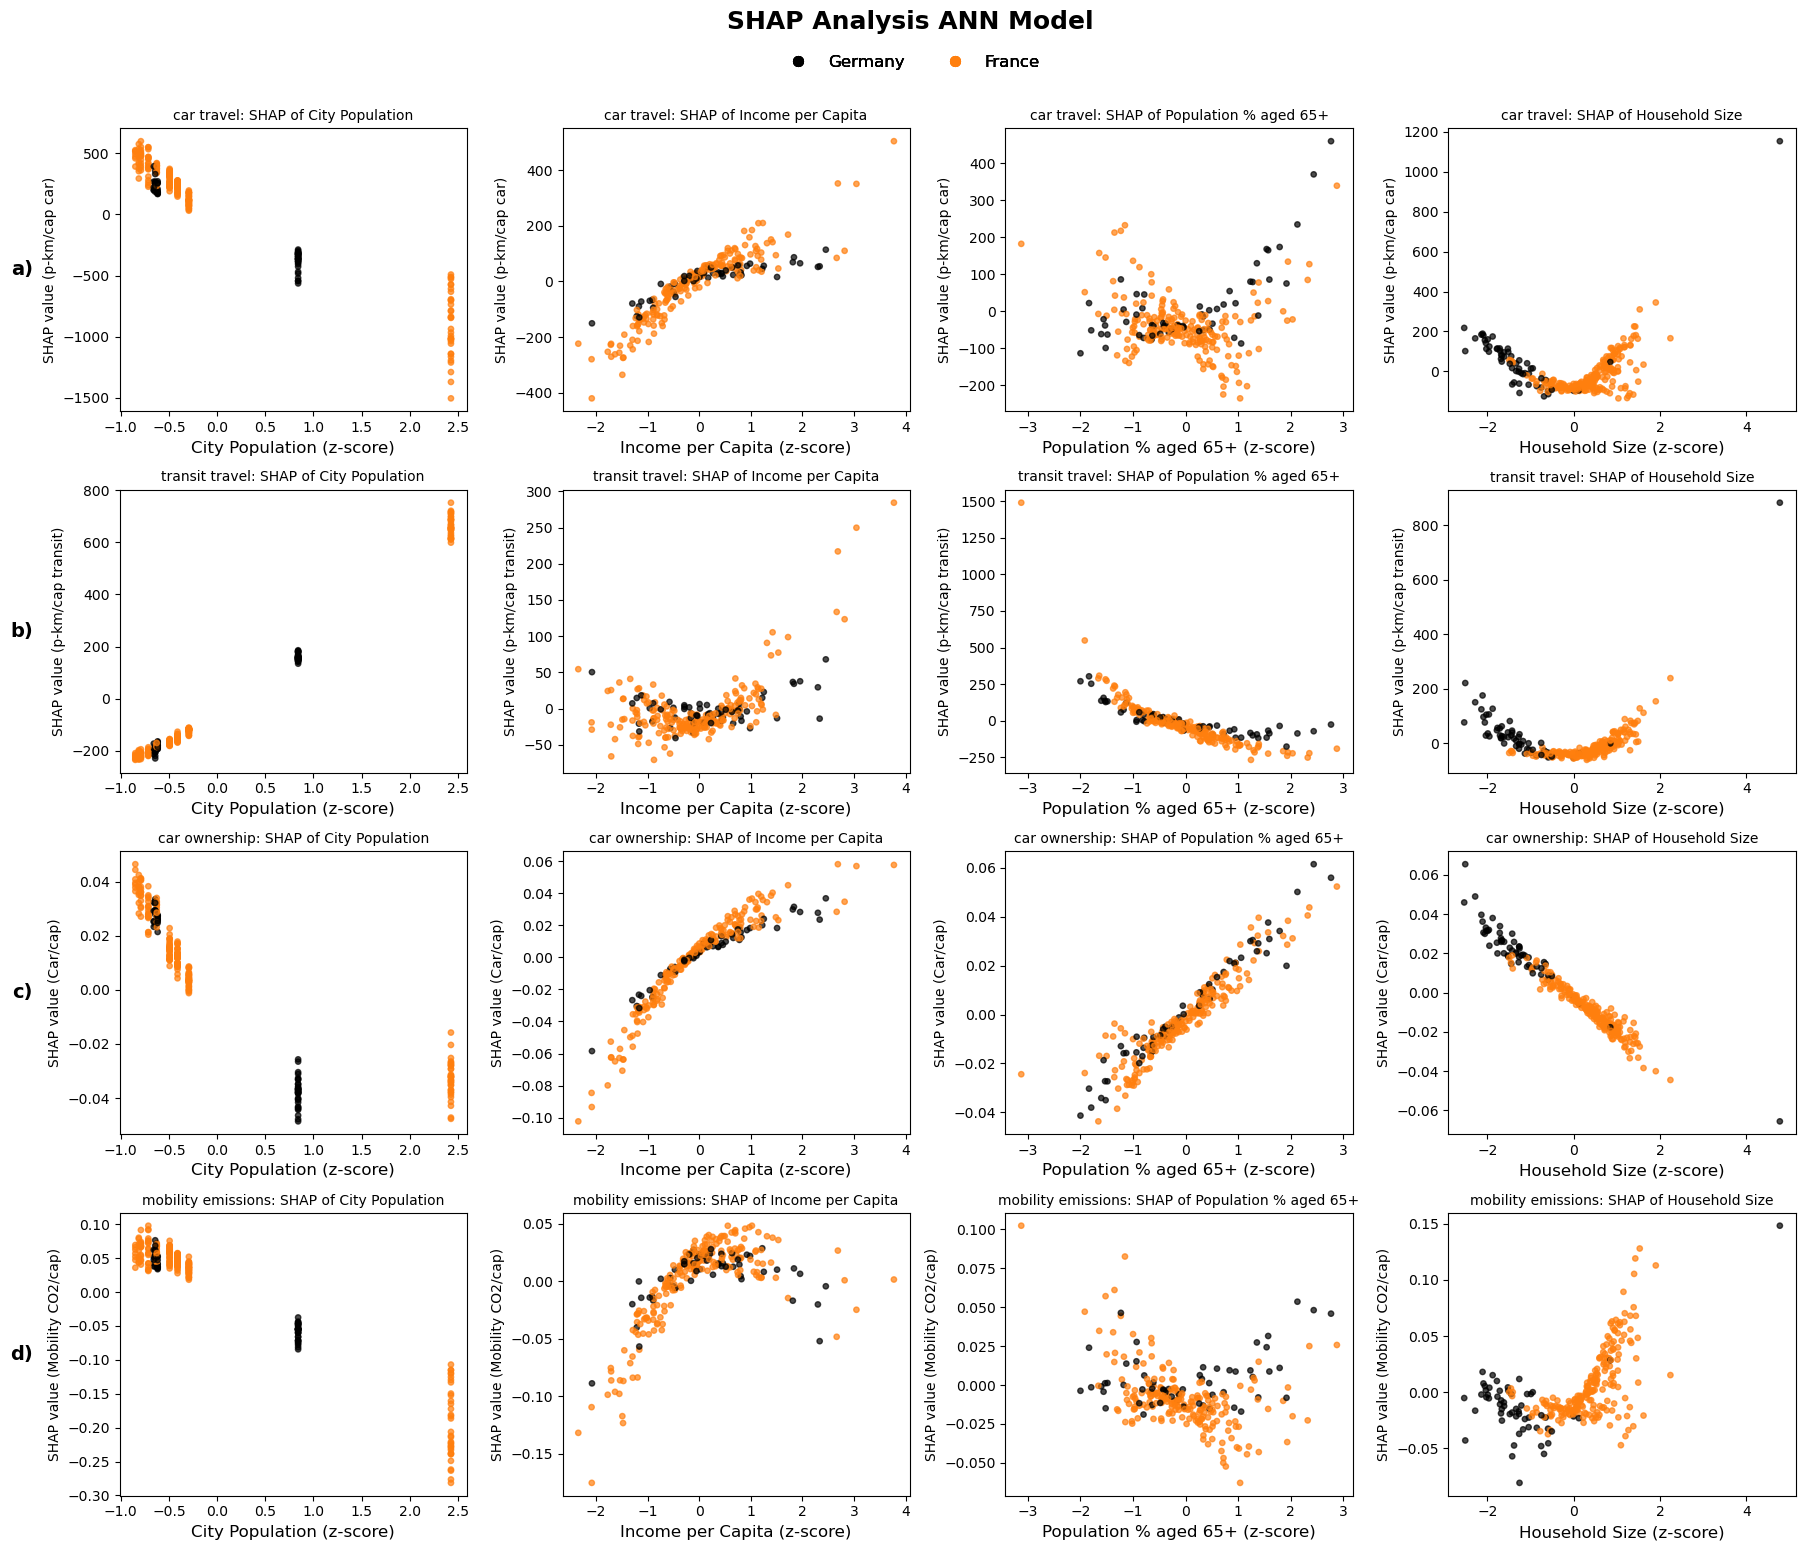

In [64]:
plot_shap_grid(
    model_type='ann',
    filename_suffix='_SI1',
    shap_dict=ann_shap,
    splits=splits_full,
    x_subset=x_subset_SI1,
    y_vars=y_vars
)

In [ ]:
def plot_shap_importance_grid(gbdt_shap, ann_shap, splits, y_vars, suffix, title, top_n=8):
    fig, axes = plt.subplots(2, len(y_vars), figsize=(20, 10))
    fig.subplots_adjust(hspace=0.4, wspace=0.3)

    ann_dict = {}
    gbdt_dict = {}

    # ---- Row 1: ANN ----
    for j, y in enumerate(y_vars):
        explainer, shap_values = ann_shap[y]
        X_train, X_test, y_train, y_test = splits[y]

        # ANN shap_values is already (n_samples, n_features)
        vals = np.abs(shap_values).mean(axis=0)
        vals_pct_ann = 100 * vals / vals.sum()

        raw_cols = X_test.columns
        mapped_names = [variable_labels_3.get(col, col) for col in raw_cols] if variable_labels_3 else raw_cols
        
        # Store ALL features in dictionary for returned DataFrames
        ann_dict[y] = pd.Series(vals_pct_ann, index=mapped_names)

        # Slice top N features (highest at the end of array -> top of barh plot)
        order_top = np.argsort(vals_pct_ann)[-top_n:]
        feature_names_plot = [mapped_names[i] for i in order_top]
        vals_plot = vals_pct_ann[order_top]

        ax = axes[0, j]
        ax.barh(
            feature_names_plot,
            vals_plot,
            color="darkorange"
        )
        ax.set_title(f"ANN — {y}", fontsize=12)
        ax.set_xlabel("Importance (% of total)")
        ax.set_xlim(left=0)

    # ---- Row 2: GBDT ----
    for j, y in enumerate(y_vars):
        explainer, shap_values = gbdt_shap[y]
        X_train, X_test, y_train, y_test = splits[y]

        vals = np.abs(shap_values.values).mean(axis=0)
        vals_pct_gbdt = 100 * vals / vals.sum()

        raw_cols = X_test.columns
        mapped_names = [variable_labels_3.get(col, col) for col in raw_cols] if variable_labels_3 else raw_cols
        
        # Store ALL features in dictionary for returned DataFrames
        gbdt_dict[y] = pd.Series(vals_pct_gbdt, index=mapped_names)

        # Slice top N features
        order_top = np.argsort(vals_pct_gbdt)[-top_n:]
        feature_names_plot = [mapped_names[i] for i in order_top]
        vals_plot = vals_pct_gbdt[order_top]

        ax = axes[1, j]
        ax.barh(
            feature_names_plot,
            vals_plot,
            color="steelblue"
        )
        ax.set_title(f"GBDT — {y}", fontsize=12)
        ax.set_xlabel("Importance (% of total)")
        ax.set_xlim(left=0)

    # ---- REDUCE VERTICAL GAP ----
    # Setting y=0.98 and tight_layout rect top to 0.97 closes the whitespace gap
    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    fig.savefig('datapaper_outputs/figures/shap_importance' + suffix + '.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Convert collected dictionaries to DataFrames
    df_ann_importance = pd.DataFrame(ann_dict)
    df_gbdt_importance = pd.DataFrame(gbdt_dict)

    return df_ann_importance, df_gbdt_importance

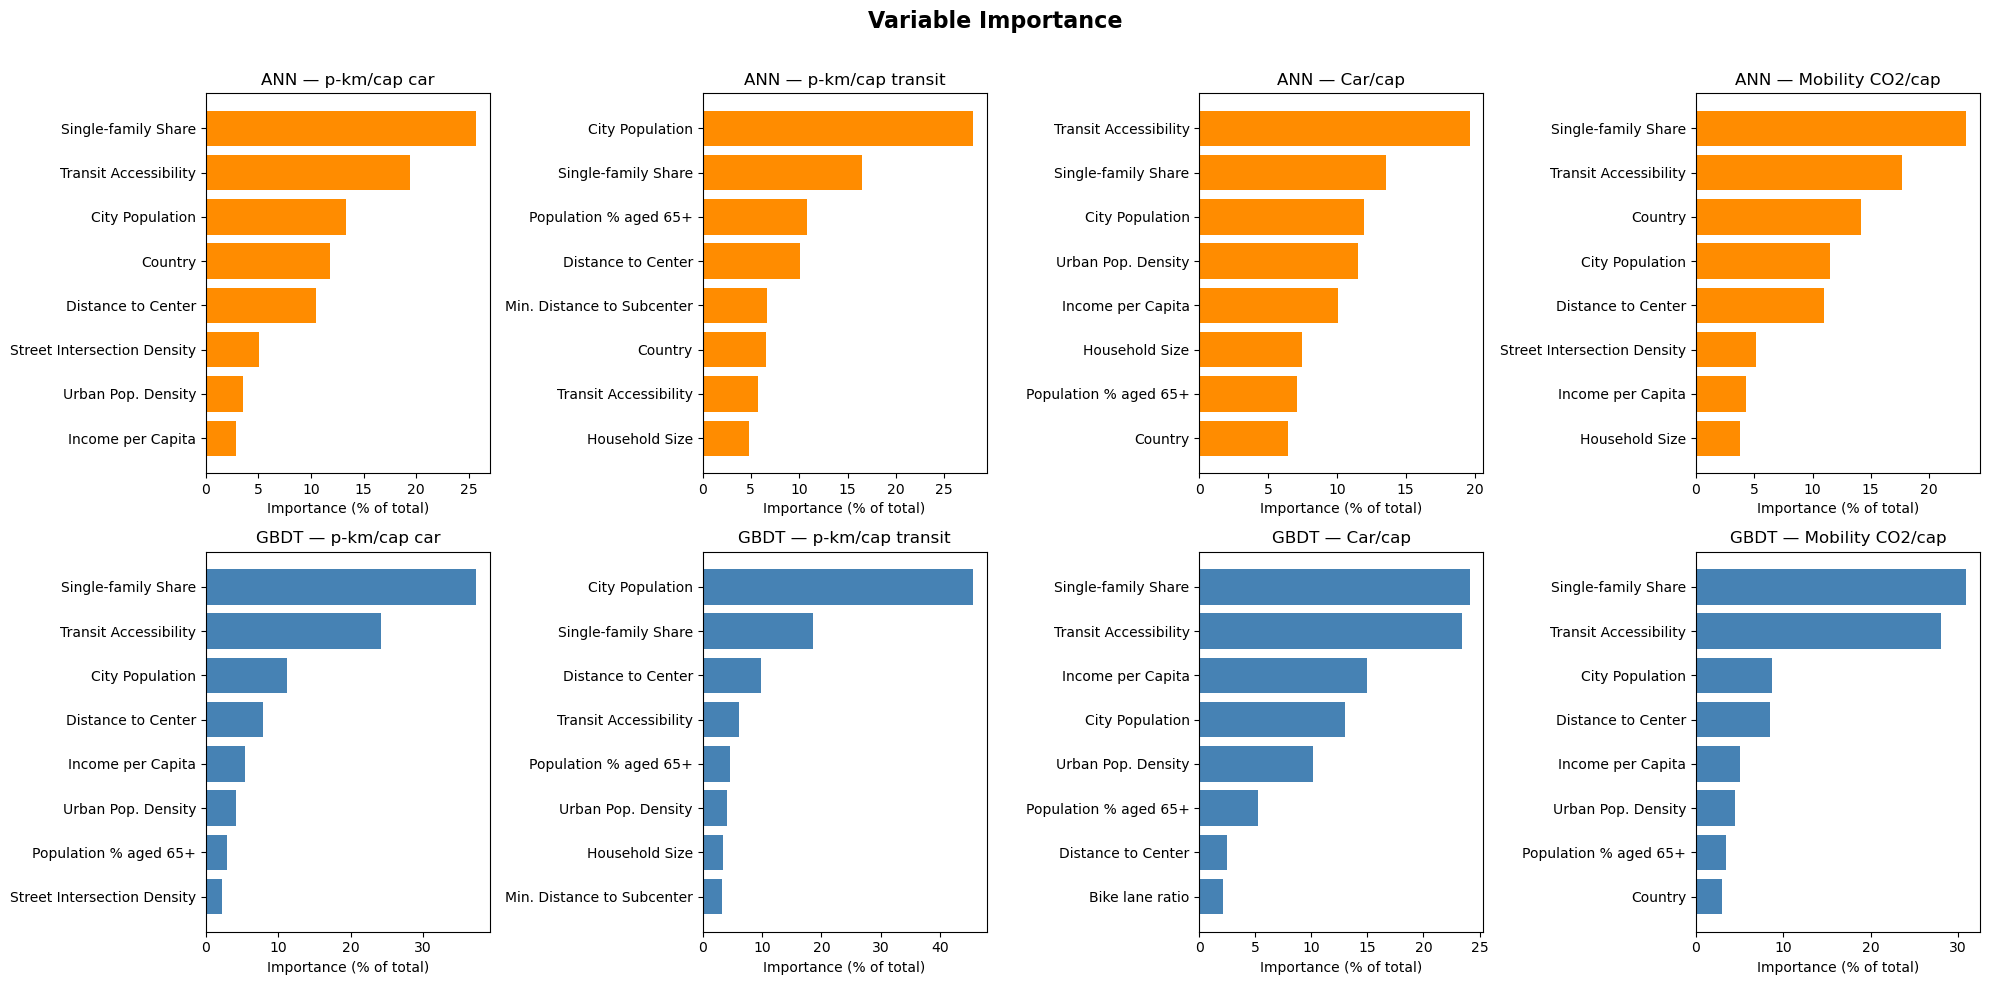

In [66]:
ann_importance, gbdt_importance = plot_shap_importance_grid(
    gbdt_shap=gbdt_shap,
    ann_shap=ann_shap,
    splits=splits_full,
    y_vars=y_vars,
    suffix='',
    title = 'Variable Importance'
)

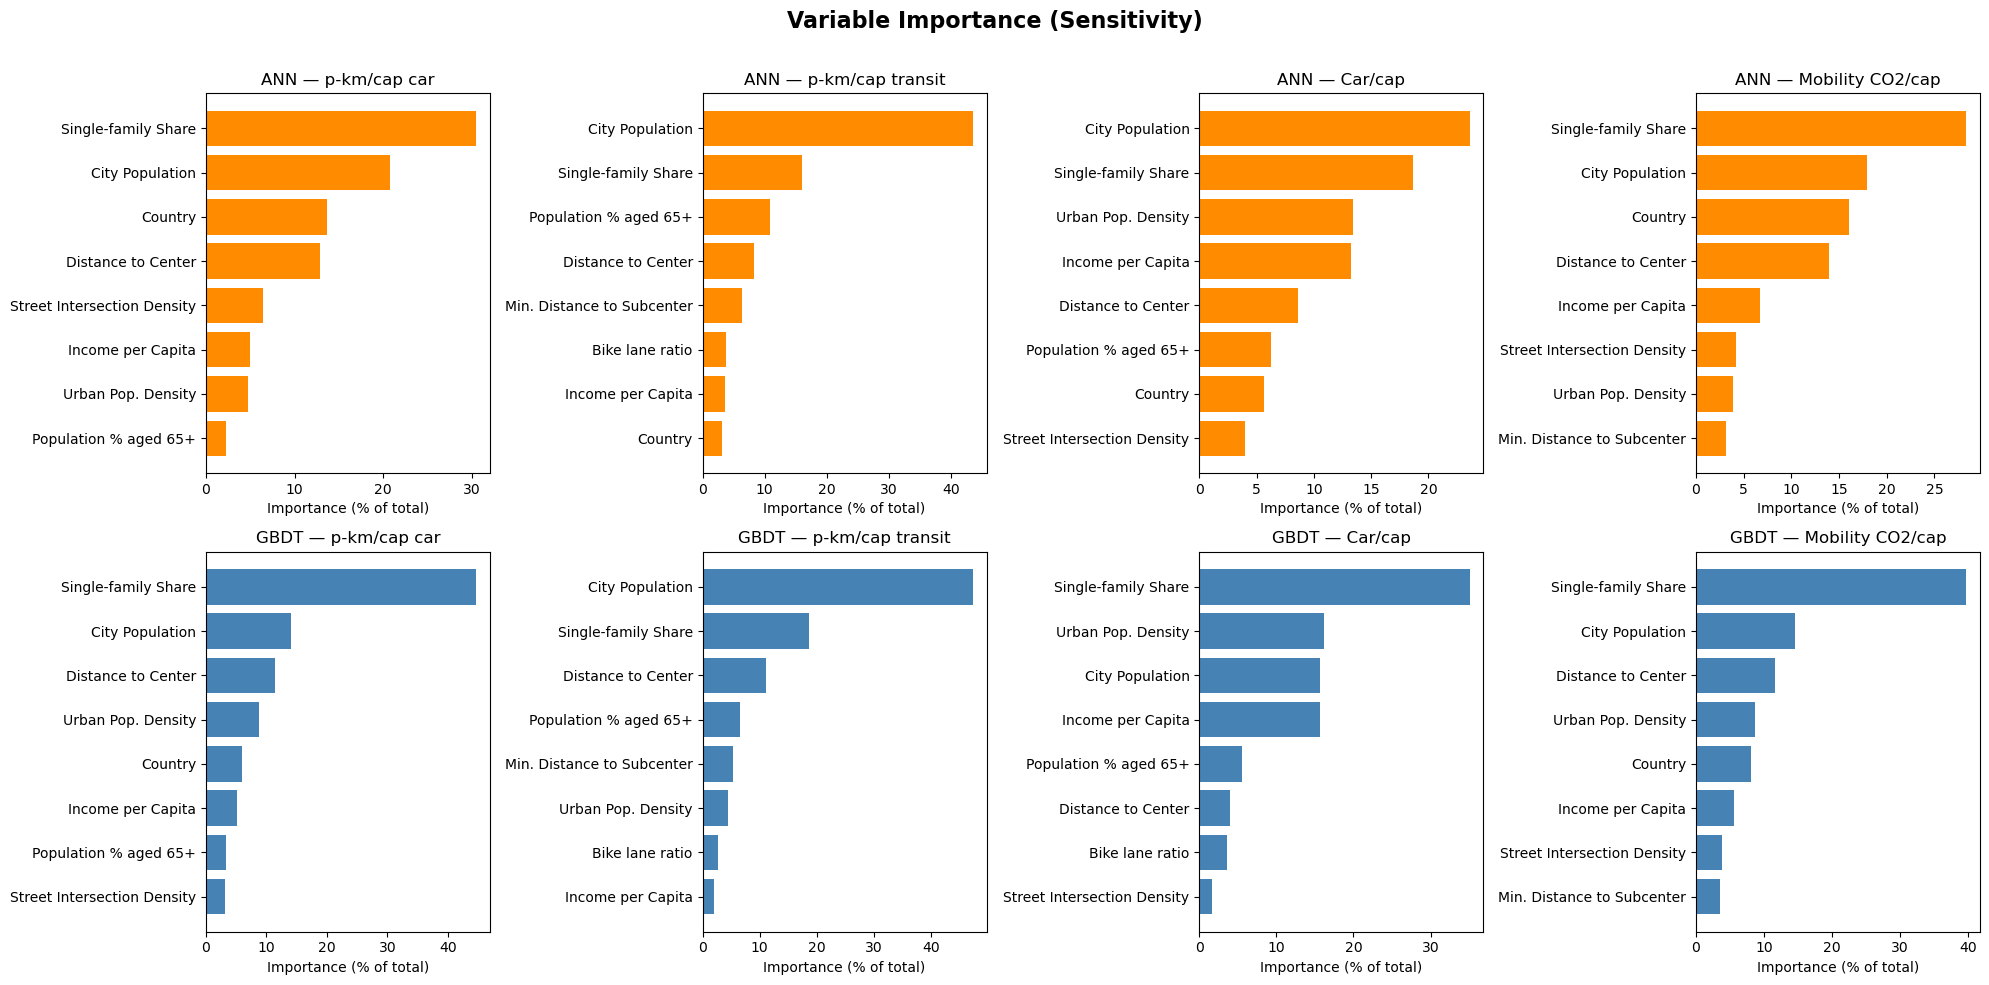

In [67]:
ann_importance_sens, gbdt_importance_sens = plot_shap_importance_grid(
    gbdt_shap=gbdt_shap_sens,
    ann_shap=ann_shap_sens,
    splits=splits_sens,
    y_vars=y_vars,
    suffix='_sens',
    title = 'Variable Importance (Sensitivity)'
)

In [ ]:
### Causal Discovery

In [ ]:
# create graphs individually then plot together

os.makedirs('datapaper_outputs/tables', exist_ok=True)
os.makedirs('datapaper_outputs/figures', exist_ok=True)

def export_graph_to_csv(cg, labels, name_suffix):
    """Exports adjacency matrix and edge list with corrected causallearn indexing."""
    adj = cg.G.graph
    n = len(labels)
    
    # 1. Adjacency matrix CSV
    df_adj = pd.DataFrame(adj, index=labels, columns=labels)
    df_adj.to_csv(f'datapaper_outputs/tables/adj_matrix_{name_suffix}.csv')
    
    # 2. Edge list CSV
    edges = []
    for i in range(n):
        for j in range(i + 1, n):
            e_A = adj[i, j]  # Endpoint mark at Node A (i)
            e_B = adj[j, i]  # Endpoint mark at Node B (j)
            
            if e_A == 0 and e_B == 0:
                continue
            
            # Directed A -> B (Tail at A, Arrow at B)
            if e_A == -1 and e_B == 2:
                edge_type, rel = "Directed", f"{labels[i]} -> {labels[j]}"
            # Directed B -> A (Arrow at A, Tail at B)
            elif e_A == 2 and e_B == -1:
                edge_type, rel = "Directed", f"{labels[j]} -> {labels[i]}"
            # Undirected A - B (Tail at A, Tail at B)
            elif e_A == -1 and e_B == -1:
                edge_type, rel = "Undirected", f"{labels[i]} - {labels[j]}"
            # Bidirected A <-> B (Arrow at A, Arrow at B)
            elif e_A == 2 and e_B == 2:
                edge_type, rel = "Bidirected", f"{labels[i]} <-> {labels[j]}"
            # Partially Oriented A -o B (Tail at A, Circle at B)
            elif e_A == -1 and e_B == 1:
                edge_type, rel = "Partially Oriented", f"{labels[i]} -o {labels[j]}"
            # Partially Oriented B -o A (Circle at A, Tail at B)
            elif e_A == 1 and e_B == -1:
                edge_type, rel = "Partially Oriented", f"{labels[j]} -o {labels[i]}"
            # Unoriented A o-o B (Circle at A, Circle at B)
            elif e_A == 1 and e_B == 1:
                edge_type, rel = "Unoriented", f"{labels[i]} o-o {labels[j]}"
            else:
                edge_type, rel = "Other", f"{labels[i]} ? {labels[j]}"
                
            edges.append({
                "Node_A": labels[i],
                "Node_B": labels[j],
                "Edge_Type": edge_type,
                "Relationship": rel,
                "Mark_at_Node_A": e_A,
                "Mark_at_Node_B": e_B
            })
            
    df_edges = pd.DataFrame(edges)
    df_edges.to_csv(f'datapaper_outputs/tables/edge_list_{name_suffix}.csv', index=False)


images=[]

# draw causal graph for each y var
y_vars_drop=y_vars.copy()
y_vars_drop.remove('p-km/cap car')
dft=df_reg.drop(columns=y_vars_drop)
labels_plot=list(dft.columns)
labels_plot=[variable_labels_3.get(item, item) for item in labels_plot]
dfnp=dft.to_numpy()

cg_without_background_knowledge = pc(dfnp)
nodes = cg_without_background_knowledge.G.get_nodes()

# target cant cause anything
target=dft.shape[1]-1
bk = BackgroundKnowledge()
for n in np.arange(0, dft.shape[1]-1,1):
    bk.add_forbidden_by_node(nodes[target], nodes[n])
# nothing can cause country
col=dft.columns.get_loc('Country_France')
for n in np.delete(np.arange(0, dft.shape[1]-1,1),col):
    bk.add_forbidden_by_node(nodes[n], nodes[col])

# nothing can cause d2c
col=dft.columns.get_loc('Distance to Center')
for n in np.delete(np.arange(0, dft.shape[1]-1,1),col):
    bk.add_forbidden_by_node(nodes[n], nodes[col])

# nothing can cause city pop
col=dft.columns.get_loc('City Population')
for n in np.delete(np.arange(0, dft.shape[1]-1,1),col):
    bk.add_forbidden_by_node(nodes[n], nodes[col])

cg_with_background_knowledge = pc(dfnp, background_knowledge=bk)

# Save Adjacency Matrix & Edge List CSVs
export_graph_to_csv(cg_with_background_knowledge, labels_plot, 'pkm_car')

# Save PNG image & append to images list
pyd = GraphUtils.to_pydot(cg_with_background_knowledge.G,labels=labels_plot)
#pyd.write_png('datapaper_outputs/figures/cg_pkm_car.png')
png_bytes = pyd.create_png()
img = Image.open(io.BytesIO(png_bytes))
images.append(img)


y_vars_drop=y_vars.copy()
y_vars_drop.remove('p-km/cap transit')
dft=df_reg.drop(columns=y_vars_drop)
labels_plot=list(dft.columns)
labels_plot=[variable_labels_3.get(item, item) for item in labels_plot]
dfnp=dft.to_numpy()

cg_without_background_knowledge = pc(dfnp)
nodes = cg_without_background_knowledge.G.get_nodes()

# target cant cause anything
target=dft.shape[1]-1
bk = BackgroundKnowledge()
for n in np.arange(0, dft.shape[1]-1,1):
    bk.add_forbidden_by_node(nodes[target], nodes[n])
# nothing can cause country
col=dft.columns.get_loc('Country_France')
for n in np.delete(np.arange(0, dft.shape[1]-1,1),col):
    bk.add_forbidden_by_node(nodes[n], nodes[col])

# nothing can cause d2c
col=dft.columns.get_loc('Distance to Center')
for n in np.delete(np.arange(0, dft.shape[1]-1,1),col):
    bk.add_forbidden_by_node(nodes[n], nodes[col])

# nothing can cause city pop
col=dft.columns.get_loc('City Population')
for n in np.delete(np.arange(0, dft.shape[1]-1,1),col):
    bk.add_forbidden_by_node(nodes[n], nodes[col])

# sfs cannot cause d2sc
col=dft.columns.get_loc('Min. dist to Subcenter')
row=dft.columns.get_loc('Single-family Share')
for n in np.delete(np.arange(0, dft.shape[1]-1,1),col):
    bk.add_forbidden_by_node(nodes[row], nodes[col])

cg_with_background_knowledge = pc(dfnp, background_knowledge=bk)

# Save Adjacency Matrix & Edge List CSVs
export_graph_to_csv(cg_with_background_knowledge, labels_plot, 'pkm_transit')

# Save PNG image & append to images list
pyd = GraphUtils.to_pydot(cg_with_background_knowledge.G,labels=labels_plot)
#pyd.write_png('datapaper_outputs/figures/cg_pkm_transit.png')
png_bytes = pyd.create_png()
img = Image.open(io.BytesIO(png_bytes))
images.append(img)


y_vars_drop=y_vars.copy()
y_vars_drop.remove('Car/cap')
dft=df_reg.drop(columns=y_vars_drop)
labels_plot=list(dft.columns)
labels_plot=[variable_labels_3.get(item, item) for item in labels_plot]
dfnp=dft.to_numpy()

cg_without_background_knowledge = pc(dfnp)
nodes = cg_without_background_knowledge.G.get_nodes()

# target cant cause anything
target=dft.shape[1]-1
bk = BackgroundKnowledge()
for n in np.arange(0, dft.shape[1]-1,1):
    bk.add_forbidden_by_node(nodes[target], nodes[n])
# nothing can cause country
col=dft.columns.get_loc('Country_France')
for n in np.delete(np.arange(0, dft.shape[1]-1,1),col):
    bk.add_forbidden_by_node(nodes[n], nodes[col])

# nothing can cause d2c
col=dft.columns.get_loc('Distance to Center')
for n in np.delete(np.arange(0, dft.shape[1]-1,1),col):
    bk.add_forbidden_by_node(nodes[n], nodes[col])

# nothing can cause city pop
col=dft.columns.get_loc('City Population')
for n in np.delete(np.arange(0, dft.shape[1]-1,1),col):
    bk.add_forbidden_by_node(nodes[n], nodes[col])

# sfs cannot cause d2sc
col=dft.columns.get_loc('Min. dist to Subcenter')
row=dft.columns.get_loc('Single-family Share')
for n in np.delete(np.arange(0, dft.shape[1]-1,1),col):
    bk.add_forbidden_by_node(nodes[row], nodes[col])


cg_with_background_knowledge = pc(dfnp, background_knowledge=bk)

# Save Adjacency Matrix & Edge List CSVs
export_graph_to_csv(cg_with_background_knowledge, labels_plot, 'car_cap')

# Save PNG image & append to images list
pyd = GraphUtils.to_pydot(cg_with_background_knowledge.G,labels=labels_plot)
#pyd.write_png('datapaper_outputs/figures/cg_car_cap.png')
png_bytes = pyd.create_png()
img = Image.open(io.BytesIO(png_bytes))
images.append(img)


y_vars_drop=y_vars.copy()
y_vars_drop.remove('Mobility CO2/cap')
dft=df_reg.drop(columns=y_vars_drop)
labels_plot=list(dft.columns)
labels_plot=[variable_labels_3.get(item, item) for item in labels_plot]
dfnp=dft.to_numpy()

cg_without_background_knowledge = pc(dfnp)
nodes = cg_without_background_knowledge.G.get_nodes()

# target cant cause anything
target=dft.shape[1]-1
bk = BackgroundKnowledge()
for n in np.arange(0, dft.shape[1]-1,1):
    bk.add_forbidden_by_node(nodes[target], nodes[n])
# nothing can cause country
col=dft.columns.get_loc('Country_France')
for n in np.delete(np.arange(0, dft.shape[1]-1,1),col):
    bk.add_forbidden_by_node(nodes[n], nodes[col])

# nothing can cause d2c
col=dft.columns.get_loc('Distance to Center')
for n in np.delete(np.arange(0, dft.shape[1]-1,1),col):
    bk.add_forbidden_by_node(nodes[n], nodes[col])

# nothing can cause city pop
col=dft.columns.get_loc('City Population')
for n in np.delete(np.arange(0, dft.shape[1]-1,1),col):
    bk.add_forbidden_by_node(nodes[n], nodes[col])

cg_with_background_knowledge = pc(dfnp, background_knowledge=bk)

# Save Adjacency Matrix & Edge List CSVs
export_graph_to_csv(cg_with_background_knowledge, labels_plot, 'co2_cap')

# Save PNG image & append to images list
pyd = GraphUtils.to_pydot(cg_with_background_knowledge.G,labels=labels_plot)
#pyd.write_png('datapaper_outputs/figures/cg_co2_cap.png')
png_bytes = pyd.create_png()
img = Image.open(io.BytesIO(png_bytes))
images.append(img)

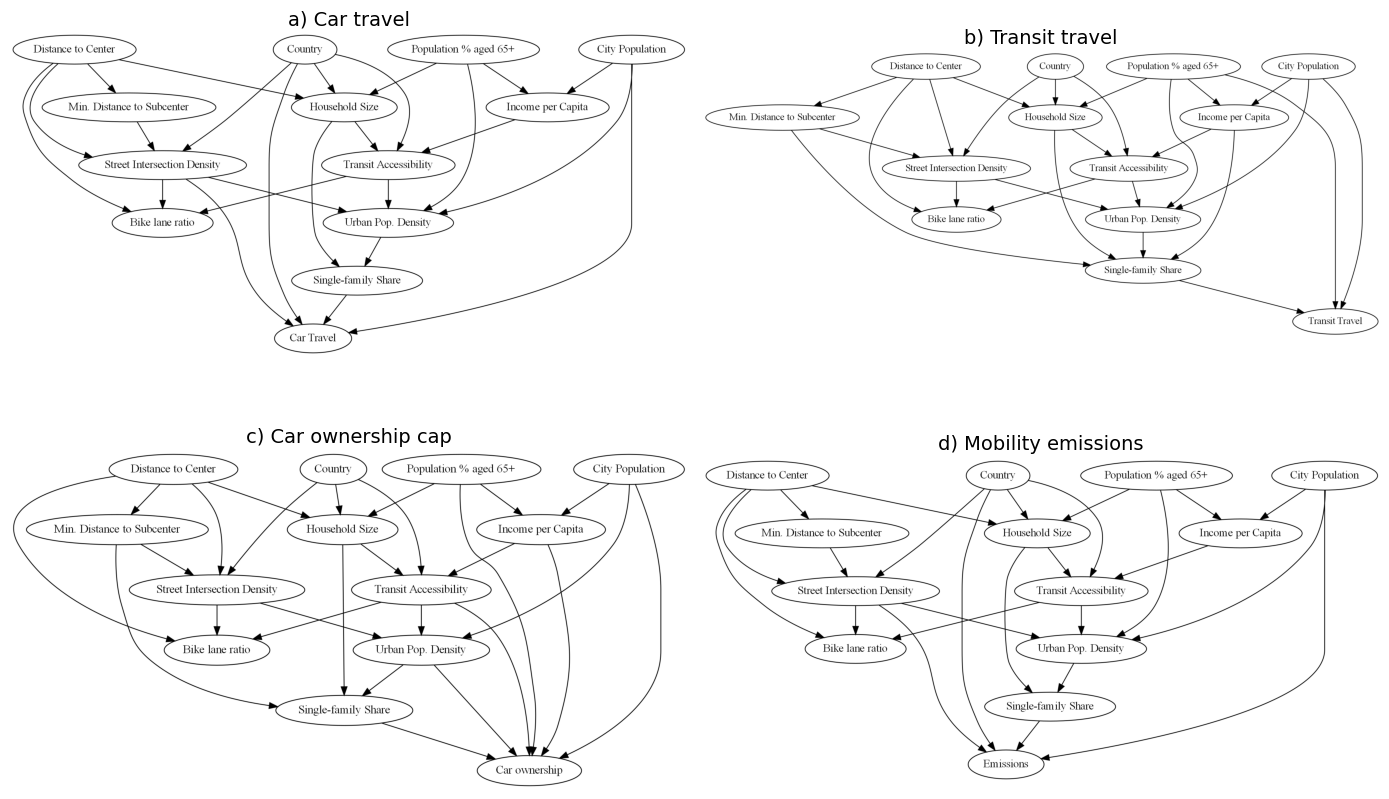

In [220]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

titles = [
    "a) Car travel",
    "b) Transit travel",
    "c) Car ownership cap",
    "d) Mobility emissions"
]

for ax, img, title in zip(axes.flatten(), images, titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=14)
    ax.axis("off")

# Reduce vertical space (hspace) and horizontal space (wspace)
fig.subplots_adjust(hspace=-0.5, wspace=0.05)

plt.tight_layout()
fig.savefig("datapaper_outputs/figures/combined_causal_graphs.png", dpi=300, bbox_inches="tight")
plt.show()

DML 

In [ ]:
def run_dml_and_summarise(df, T_specs, y_vars, W_cols, X_cols, make_xgb):
    """
    Runs LinearDML for each treatment-outcome combination.
    Dynamically adjusts W based on the specific treatment's position in the DAG.
    Returns:
      - summary DataFrame with ATE, CI, CATE SD, nuisance R2
      - dictionary of CATE vectors for mapping/plotting
    """

    results = []
    cate_store = {}   # (treatment, outcome) → pd.Series of CATE

    index = df.index  # preserve original index for mapping

    for t_name, t_col in T_specs.items():
        
        # --- Dynamically adjust W for this specific treatment ---
        # Create a fresh copy of W_cols so modifications don't bleed into the next loop
        current_W_cols = W_cols.copy() 
        
        if t_name == 'Single-family Share':
            # Add Density to W to block confounding (as dictated by the DAG)
            current_W_cols.append('Urban Pop. Density')

        # --- Standardize treatment ---
        T_raw = df[[t_col]].values
        T_std = (T_raw - T_raw.mean()) / T_raw.std()
        T_std = T_std.ravel()

        # Extract features using the dynamically updated W
        W = df[current_W_cols].values
        X = df[X_cols].values

        for y_col in y_vars:
            Y = df[y_col].values

            # --- Nuisance models ---
            model_y = make_xgb()
            model_t = make_xgb()

            dml = LinearDML(
                model_y=model_y,
                model_t=model_t,
                featurizer=None,
                cv=3,
                random_state=42
            )

            dml.fit(Y, T_std, X=X, W=W)

            # --- Effects ---
            cate = dml.effect(X)
            ate = cate.mean()
            cate_sd = cate.std()

            # # --- Confidence interval ---

            # --- CATE vector aligned with df index ---
            cate_vec = pd.Series(
                cate,
                index=index,
                name=f"CATE_{t_name}_{y_col}"
            )
            cate_store[(t_name, y_col)] = cate_vec

            # --- Nuisance R² ---
            r2_y = np.mean(dml.nuisance_scores_y)
            r2_t = np.mean(dml.nuisance_scores_t)

            # --- Store summary ---
            results.append({
                'Treatment': t_name,
                'Outcome': y_col,
                'ATE': ate,
                # 'ATE_CI_lower': ate_ci_low,
                # 'ATE_CI_upper': ate_ci_high,
                'CATE_sd': cate_sd,
                'R2(Y ~ W,X)': r2_y,
                'R2(T ~ W,X)': r2_t,
                'N': len(Y),
                'W_features_used': len(current_W_cols) # Optional: helpful for verification
            })

    summary_df = pd.DataFrame(results)
    return summary_df, cate_store

In [184]:
def make_xgb():
    return XGBRegressor(
        n_estimators=350,
        max_depth=3,
        learning_rate=0.01,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    )


In [ ]:
# run two models

W_cols1 = ['City Population', 'Country_France','Distance to Center','Inc_cap_std','HH_size', 'share_65+']
X_cols1 = ['Transit Accessibility','intersec_density']

W_cols2 = ['City Population', 'Country_France','Distance to Center','Inc_cap_std','HH_size', 'share_65+']
X_cols2 = ['Transit Accessibility', 'Min. dist to Subcenter','intersec_density']

summary_df1, cate_store1 = run_dml_and_summarise(
    df=df,
    T_specs=T_specs,
    y_vars=y_vars,
    W_cols=W_cols1,
    X_cols=X_cols1,
    make_xgb=make_xgb,
)

summary_df2, cate_store2 = run_dml_and_summarise(
    df=df,
    T_specs=T_specs,
    y_vars=y_vars,
    W_cols=W_cols2,
    X_cols=X_cols2,
    make_xgb=make_xgb,
)

In [ ]:
cate_colnames=[]
for (treatment, outcome), cate_vec in cate_store1.items():
    colname = f"CATE1_{treatment}_{outcome}"
    df[colname] = cate_vec
    cate_colnames.append(colname)

cate_colnames=[]
for (treatment, outcome), cate_vec in cate_store2.items():
    colname = f"CATE2_{treatment}_{outcome}"
    df[colname] = cate_vec
    cate_colnames.append(colname)

In [229]:
summary_df1.to_csv('datapaper_outputs/DML_summary1.csv',index=False)
summary_df2.to_csv('datapaper_outputs/DML_summary2.csv',index=False)


In [151]:
df.to_csv('datapaper_outputs/df_cate.csv',index=False)

In [194]:
cities=df['Region'].unique()

In [ ]:
treatments = ['Single-family Share', 'Urban Pop. Density']
outcomes = ['p-km/cap car', 'p-km/cap transit', 'Car/cap', 'Mobility CO2/cap']
cate_versions = [1, 2]
# Short codes for clean filenames
treatment_codes = {
    'Single-family Share': 'sfs',
    'Urban Pop. Density': 'upd'
}
outcome_codes = {
    'p-km/cap car': 'carpkm',
    'p-km/cap transit': 'transitpkm',
    'Car/cap': 'carcap',
    'Mobility CO2/cap': 'co2cap'
}

# Pre-load centers file
fp_centers = '../../sufficcs_mobility/source/citycenters/centers.csv'
centers_all = import_csv_w_wkt_to_gdf(fp_centers, crs=4326)
centers_all.to_crs(3035, inplace=True)

# Outer Loop: Cities
for city in cities:
    fp_gpkg = f'../../sufficcs_mobility/source/GTFS/postcodes_gpkg_all/{city}_postcodes.gpkg'

    gdf_city_base = gpd.read_file(fp_gpkg)
    gdf_city_base.to_crs(3035, inplace=True)
    gdf_city_base['geocode'] = gdf_city_base['geocode'].astype(str)
    
    cp = centers_all.loc[centers_all['City'] == city]

    # Inner Loops: Treatment x Outcome x Version
    for tr in treatments:
        for out in outcomes:
            for v in cate_versions:
                # Dynamic column name (e.g., 'CATE1_Single-family Share_p-km/cap car')
                t_o = f'CATE{v}_{tr}_{out}'
                
                if t_o not in df.columns:
                    print(f"Column '{t_o}' not found in df. Skipping...")
                    continue
                    
                gdf_city = gdf_city_base.merge(df.loc[:, ['geocode', t_o]], on='geocode')

                fig, ax = plt.subplots(figsize=(10, 7))
                
                gdf_city.plot(column=t_o, legend=True, ax=ax, cmap='coolwarm')
                if not cp.empty:
                    cp.plot(color='k', ax=ax)
                    
                plt.axis('off')
                plt.title(f'CATE {tr} → {out}, {city} (model {v})', fontsize=15)

                # Scale Bar & North Arrow
                scalebar = ScaleBar(1, location='lower left', font_properties={'size': 13}, frameon=False)
                ax.add_artist(scalebar)

                # Colorbar Formatting
                if len(fig.axes) > 1:
                    cb_ax = fig.axes[1] 
                    cb_ax.tick_params(labelsize=13)
                    cb_ax.set_ylabel('CATE', rotation=0, fontsize=13, labelpad=15)

                plt.tight_layout()
                
                # Dynamic Output Path with Model Version Suffix (_1, _2, _3)
                tr_code = treatment_codes.get(tr, tr.lower().replace(' ', ''))
                out_code = outcome_codes.get(out, out.lower().replace(' ', ''))
                out_path = f'datapaper_outputs/figures/cate_maps/CATE_{tr_code}_{out_code}_{city}_{v}.png'
                
                plt.savefig(out_path, facecolor='w', dpi=300, bbox_inches='tight')
                plt.close(fig)  # Free up memory

print("All maps generated successfully!")

All maps generated successfully!
